In [2]:
import pandas as pd

df_2016 = pd.read_csv("ETH_Ward (2016).csv")
df_2021 = pd.read_csv("ETH_Ward (2021).csv")


In [3]:
print("2016 shape:", df_2016.shape)
print("2021 shape:", df_2021.shape)

print("\n2016 columns:")
print(df_2016.columns.tolist())

print("\n2021 columns:")
print(df_2021.columns.tolist())

print("\n2016 wards:", df_2016["Ward"].nunique())
print("2021 wards:", df_2021["Ward"].nunique())

print("\n2016 voting districts:", df_2016["VotingDistrict"].nunique())
print("2021 voting districts:", df_2021["VotingDistrict"].nunique())

print("\n2016 parties:", df_2016["PartyName"].nunique())
print("2021 parties:", df_2021["PartyName"].nunique())

2016 shape: (40706, 11)
2021 shape: (32990, 11)

2016 columns:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']

2021 columns:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']

2016 wards: 110
2021 wards: 111

2016 voting districts: 866
2021 voting districts: 875

2016 parties: 28
2021 parties: 53


In [4]:
print("\n2016 ballot types:")
print(df_2016["BallotType"].value_counts())

print("\n2021 ballot types:")
print(df_2021["BallotType"].value_counts())


2016 ballot types:
BallotType
PR      23382
Ward    17324
Name: count, dtype: int64

2021 ballot types:
BallotType
Ward    32990
Name: count, dtype: int64


In [5]:
 #Get the unique ward identifiers from each election
wards_2016 = set(df_2016["Ward"].unique())
wards_2021 = set(df_2021["Ward"].unique())

# Find wards that appear in one year but not the other
wards_only_2016 = wards_2016 - wards_2021
wards_only_2021 = wards_2021 - wards_2016

print("Wards only in 2016:", wards_only_2016)
print("Wards only in 2021:", wards_only_2021)

Wards only in 2016: set()
Wards only in 2021: {'Ward 59500111'}


In [6]:
# Get unique voting districts for each election
vd_2016 = set(df_2016["VotingDistrict"].unique())
vd_2021 = set(df_2021["VotingDistrict"].unique())

# Compare them
vd_only_2016 = vd_2016 - vd_2021
vd_only_2021 = vd_2021 - vd_2016

print("Voting districts only in 2016:", vd_only_2016)
print("Voting districts only in 2021:", vd_only_2021)

Voting districts only in 2016: {np.int64(44070027), np.int64(43362356), np.int64(43583373)}
Voting districts only in 2021: {np.int64(43584644), np.int64(43380389), np.int64(43584712), np.int64(43391145), np.int64(43584655), np.int64(43380367), np.int64(43400944), np.int64(43391156), np.int64(43380378), np.int64(43584633), np.int64(43584666), np.int64(43584767)}


In [7]:
# Create a mapping of Voting District -> Ward for each election
vd_ward_2016 = df_2016[["VotingDistrict", "Ward"]].drop_duplicates()
vd_ward_2021 = df_2021[["VotingDistrict", "Ward"]].drop_duplicates()

# Merge the two mappings
vd_comparison = vd_ward_2016.merge(
    vd_ward_2021,
    on="VotingDistrict",
    how="outer",
    suffixes=("_2016", "_2021")
)

# Find voting districts whose ward assignment changed
changed_vd = vd_comparison[
    vd_comparison["Ward_2016"] != vd_comparison["Ward_2021"]
]

print("Voting districts with different ward assignments:",
      len(changed_vd))

print(changed_vd.head(20))

Voting districts with different ward assignments: 82
     VotingDistrict      Ward_2016      Ward_2021
6          43350072  Ward 59500102  Ward 59500059
7          43350083  Ward 59500102  Ward 59500059
10         43350117  Ward 59500061  Ward 59500062
18         43350195  Ward 59500106  Ward 59500058
42         43350465  Ward 59500035  Ward 59500102
56         43360051  Ward 59500059  Ward 59500053
66         43360152  Ward 59500031  Ward 59500027
72         43360219  Ward 59500025  Ward 59500027
75         43360242  Ward 59500025  Ward 59500031
79         43360286  Ward 59500025  Ward 59500031
85         43360343  Ward 59500025  Ward 59500023
87         43360365  Ward 59500023  Ward 59500025
101        43360512  Ward 59500034  Ward 59500011
112        43360624  Ward 59500110  Ward 59500039
118        43360680  Ward 59500039  Ward 59500104
133        43360848  Ward 59500104  Ward 59500045
134        43360859  Ward 59500104  Ward 59500045
162        43361164  Ward 59500054  Ward 595000

In [8]:
# Check for missing values in each dataset
print("Missing values - 2016")
print(df_2016.isnull().sum())

print("\nMissing values - 2021")
print(df_2021.isnull().sum())

Missing values - 2016
Province             0
Municipality         0
Ward                 0
VotingDistrict       0
VotingStationName    0
RegisteredVoters     0
BallotType           0
SpoiltVotes          0
PartyName            0
TotalValidVotes      0
DateGenerated        0
dtype: int64

Missing values - 2021
Province             0
Municipality         0
Ward                 0
VotingDistrict       0
VotingStationName    0
RegisteredVoters     0
BallotType           0
SpoiltVotes          0
PartyName            0
TotalValidVotes      0
DateGenerated        0
dtype: int64


In [9]:
print("Duplicate rows - 2016:", df_2016.duplicated().sum())
print("Duplicate rows - 2021:", df_2021.duplicated().sum())

Duplicate rows - 2016: 0
Duplicate rows - 2021: 0


In [10]:
print("2016 numerical summary:")
print(df_2016[[
    "RegisteredVoters",
    "SpoiltVotes",
    
    "TotalValidVotes"
]].describe())

print("\n2021 numerical summary:")
print(df_2021[[
    
    "RegisteredVoters",
    "SpoiltVotes",
    "TotalValidVotes"
]].describe())

2016 numerical summary:
       RegisteredVoters   SpoiltVotes  TotalValidVotes
count      40706.000000  40706.000000     40706.000000
mean        2218.242618     29.917383        54.675109
std         1216.222531     51.968268       231.244162
min          101.000000      0.000000         0.000000
25%         1376.000000      6.000000         0.000000
50%         2098.000000     17.000000         1.000000
75%         2827.000000     36.000000         6.000000
max         8099.000000    993.000000      4175.000000

2021 numerical summary:
       RegisteredVoters   SpoiltVotes  TotalValidVotes
count      32990.000000  32990.000000     32990.000000
mean        2185.880115     16.501576        23.522734
std         1189.342444     19.547402       111.847546
min          107.000000      0.000000         0.000000
25%         1363.000000      4.000000         0.000000
50%         2057.000000     12.000000         0.000000
75%         2823.000000     22.000000         3.000000
max         7910

In [11]:
# Check whether the two datasets are completely identical
print("Are the two datasets completely identical?")
print(df_2016.equals(df_2021))

Are the two datasets completely identical?
False


In [12]:
# Compare the number of wards, voting districts and parties again
print("2016 wards:", df_2016["Ward"].nunique())
print("2021 wards:", df_2021["Ward"].nunique())

print("2016 voting districts:", df_2016["VotingDistrict"].nunique())
print("2021 voting districts:", df_2021["VotingDistrict"].nunique())

print("2016 parties:", df_2016["PartyName"].nunique())
print("2021 parties:", df_2021["PartyName"].nunique())


2016 wards: 110
2021 wards: 111
2016 voting districts: 866
2021 voting districts: 875
2016 parties: 28
2021 parties: 53


In [13]:
#The 2016 and 2021 eThekwini election datasets were not assumed to be geographically identical. 
#The 2016 dataset contains 110 wards and 866 voting districts, while the 2021 dataset contains 111 wards and 875 voting districts. 
#Therefore, ward and voting-district identifiers were treated as time-dependent geographic units and required alignment before historical comparisons were made.

In [14]:
#Compare ward identifiers between 2016 and 2021

wards_2016 = set(df_2016["Ward"].unique())
wards_2021 = set(df_2021["Ward"].unique())

print("Wards only in 2016:")
print(sorted(wards_2016 - wards_2021))

print("\nWards only in 2021:")
print(sorted(wards_2021 - wards_2016))

Wards only in 2016:
[]

Wards only in 2021:
['Ward 59500111']


In [15]:
# Compare voting-district identifiers between 2016 and 2021

vd_2016 = set(df_2016["VotingDistrict"].unique())
vd_2021 = set(df_2021["VotingDistrict"].unique())

print("Voting districts only in 2016:")
print(sorted(vd_2016 - vd_2021))

print("\nVoting districts only in 2021:")
print(sorted(vd_2021 - vd_2016))

Voting districts only in 2016:
[np.int64(43362356), np.int64(43583373), np.int64(44070027)]

Voting districts only in 2021:
[np.int64(43380367), np.int64(43380378), np.int64(43380389), np.int64(43391145), np.int64(43391156), np.int64(43400944), np.int64(43584633), np.int64(43584644), np.int64(43584655), np.int64(43584666), np.int64(43584712), np.int64(43584767)]


In [16]:
print("2016 wards:", len(wards_2016))
print("2021 wards:", len(wards_2021))

print("\nNew 2021 ward:")
print(df_2021[df_2021["Ward"] == "Ward 59500111"].head())

print("\nVoting districts in new 2021 ward:")
print(
    df_2021[df_2021["Ward"] == "Ward 59500111"]
    [["Ward", "VotingDistrict", "VotingStationName"]]
    .drop_duplicates()
)

2016 wards: 110
2021 wards: 111

New 2021 ward:
            Province     Municipality           Ward  VotingDistrict  \
32804  KwaZulu-Natal  ETH - eThekwini  Ward 59500111        43370445   
32805  KwaZulu-Natal  ETH - eThekwini  Ward 59500111        43370445   
32806  KwaZulu-Natal  ETH - eThekwini  Ward 59500111        43370445   
32807  KwaZulu-Natal  ETH - eThekwini  Ward 59500111        43370445   
32808  KwaZulu-Natal  ETH - eThekwini  Ward 59500111        43370445   

            VotingStationName  RegisteredVoters BallotType  SpoiltVotes  \
32804  ZWELIBANZI HIGH SCHOOL              3826       Ward           29   
32805  ZWELIBANZI HIGH SCHOOL              3826       Ward           29   
32806  ZWELIBANZI HIGH SCHOOL              3826       Ward           29   
32807  ZWELIBANZI HIGH SCHOOL              3826       Ward           29   
32808  ZWELIBANZI HIGH SCHOOL              3826       Ward           29   

                                PartyName  TotalValidVotes  \
32804 

In [17]:
vd_changes = pd.concat([
    pd.DataFrame({
        "VotingDistrict": list(vd_2016 - vd_2021),
        "Status": "2016 only"
    }),
    pd.DataFrame({
        "VotingDistrict": list(vd_2021 - vd_2016),
        "Status": "2021 only"
    })
], ignore_index=True)

print(vd_changes)

    VotingDistrict     Status
0         44070027  2016 only
1         43362356  2016 only
2         43583373  2016 only
3         43584644  2021 only
4         43380389  2021 only
5         43584712  2021 only
6         43391145  2021 only
7         43584655  2021 only
8         43380367  2021 only
9         43400944  2021 only
10        43391156  2021 only
11        43380378  2021 only
12        43584633  2021 only
13        43584666  2021 only
14        43584767  2021 only


In [18]:
# See the ward associated with each changed voting district

changed_vds = set(vd_2016 ^ vd_2021)

print(
    pd.concat([
        df_2016[df_2016["VotingDistrict"].isin(changed_vds)][
            ["Ward", "VotingDistrict", "VotingStationName"]
        ],
        df_2021[df_2021["VotingDistrict"].isin(changed_vds)][
            ["Ward", "VotingDistrict", "VotingStationName"]
        ]
    ]).drop_duplicates().sort_values(["VotingDistrict", "Ward"])
)

                Ward  VotingDistrict                   VotingStationName
39723  Ward 59500107        43362356                     ZIZAMELE CRECHE
25438  Ward 59500089        43380367          SIFUNULWAZI COMMUNITY HALL
27153  Ward 59500095        43380378        METHODIST CHURCH (KWADODOZA)
28420  Ward 59500099        43380389      NKANGALA TRIBAL AUTHORITY HALL
21201  Ward 59500072        43391145                SINETHEMBA SN CRECHE
21240  Ward 59500072        43391156                       DEMAT CRECHE'
2812   Ward 59500007        43400944                EMAFUTHENI REST ROOM
34167  Ward 59500096        43583373  SUNDUZWAYO COMBINED PRIMARY SCHOOL
1690   Ward 59500003        43584633             MANDOSI COMBINED SCHOOL
32275  Ward 59500108        43584644                   KHULAKAHLE CRECHE
27803  Ward 59500096        43584655          FELOKWAKHE MKHIZE(EZIGENI)
27839  Ward 59500096        43584666               UCC MPUMALANGA CHURCH
3267   Ward 59500008        43584712               

In [19]:
# Compare the voting districts belonging to each common ward
# between the 2016 and 2021 elections.

common_wards = sorted(wards_2016 & wards_2021)

ward_changes = []

for ward in common_wards:
    vd16 = set(
        df_2016.loc[df_2016["Ward"] == ward, "VotingDistrict"].unique()
    )
    
    vd21 = set(
        df_2021.loc[df_2021["Ward"] == ward, "VotingDistrict"].unique()
    )
    
    if vd16 != vd21:
        ward_changes.append({
            "Ward": ward,
            "2016_VDs": len(vd16),
            "2021_VDs": len(vd21),
            "VDs_added": len(vd21 - vd16),
            "VDs_removed": len(vd16 - vd21)
        })

ward_changes_df = pd.DataFrame(ward_changes)

print("Common wards with changed voting-district composition:")
print(ward_changes_df)

print("\nNumber of affected common wards:", len(ward_changes_df))

Common wards with changed voting-district composition:
             Ward  2016_VDs  2021_VDs  VDs_added  VDs_removed
0   Ward 59500002        19        22          3            0
1   Ward 59500003        13        13          5            5
2   Ward 59500007         6         7          1            0
3   Ward 59500008        13        12          1            2
4   Ward 59500009        11        10          0            1
5   Ward 59500010         7         9          2            0
6   Ward 59500011         7         8          1            0
7   Ward 59500017         7         8          1            0
8   Ward 59500019         8         7          0            1
9   Ward 59500023         8         8          1            1
10  Ward 59500025         9         6          1            4
11  Ward 59500027         7         9          2            0
12  Ward 59500029         5         6          1            0
13  Ward 59500030         8         7          0            1
14  Ward 595000

In [20]:
#I MADE THE PARAGRAPH IN LINES TO ACCOMODATE THE COMMENT SIGN
#Geographic alignment: Election results were first examined at voting-district and ward level to identify changes in geographic composition between election years. 
#The 2016 eThekwini dataset contained 110 wards and 866 voting districts, while the 2021 dataset contained 111 wards and 875 voting districts. 
#Furthermore, 57 wards common to both datasets had changes in their underlying voting-district composition. 
#Consequently, voting districts were not treated as temporally identical observations.
#Historical results were aggregated to their respective election-year ward structures, with election year retained as an explicit temporal identifier. 
#Historical ward comparisons were therefore interpreted as election-year observations rather than assuming unchanged geographic boundaries.#

In [21]:

for name, data in [("2016", df_2016), ("2021", df_2021)]:
    print(f"\n===== {name} DATASET =====")
    print(data.info())
    print("\nMissing values:")
    print(data.isnull().sum())


===== 2016 DATASET =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40706 entries, 0 to 40705
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Province           40706 non-null  object
 1   Municipality       40706 non-null  object
 2   Ward               40706 non-null  object
 3   VotingDistrict     40706 non-null  int64 
 4   VotingStationName  40706 non-null  object
 5   RegisteredVoters   40706 non-null  int64 
 6   BallotType         40706 non-null  object
 7   SpoiltVotes        40706 non-null  int64 
 8   PartyName          40706 non-null  object
 9   TotalValidVotes    40706 non-null  int64 
 10  DateGenerated      40706 non-null  object
dtypes: int64(4), object(7)
memory usage: 3.4+ MB
None

Missing values:
Province             0
Municipality         0
Ward                 0
VotingDistrict       0
VotingStationName    0
RegisteredVoters     0
BallotType           0
SpoiltVotes          

In [22]:
# Step 3.2 — Standardise data types and text fields

for df in [df_2016, df_2021]:

    # Convert date to datetime
    df["DateGenerated"] = pd.to_datetime(
        df["DateGenerated"],
        errors="coerce"
    )

    # Remove accidental whitespace from text fields
    text_columns = [
        "Province",
        "Municipality",
        "Ward",
        "VotingStationName",
        "BallotType",
        "PartyName"
    ]

    for col in text_columns:
        df[col] = df[col].astype(str).str.strip()

# Check results
print("2016 Date type:", df_2016["DateGenerated"].dtype)
print("2021 Date type:", df_2021["DateGenerated"].dtype)

print("\n2016 invalid dates:",
      df_2016["DateGenerated"].isna().sum())

print("2021 invalid dates:",
      df_2021["DateGenerated"].isna().sum())

2016 Date type: datetime64[ns]
2021 Date type: datetime64[ns]

2016 invalid dates: 0
2021 invalid dates: 0


In [23]:
# Step 3.3 — Validate duplicates and numerical values

for name, data in [("2016", df_2016), ("2021", df_2021)]:

    print(f"\n===== {name} VALIDATION =====")

    # Duplicate rows
    print("Duplicate rows:", data.duplicated().sum())

    # Negative values
    print("Negative RegisteredVoters:",
          (data["RegisteredVoters"] < 0).sum())

    print("Negative SpoiltVotes:",
          (data["SpoiltVotes"] < 0).sum())

    print("Negative TotalValidVotes:",
          (data["TotalValidVotes"] < 0).sum())

    # Basic logical check
    print("Valid votes greater than registered voters:",
          (data["TotalValidVotes"] > data["RegisteredVoters"]).sum())

    print("Spoilt votes greater than registered voters:",
          (data["SpoiltVotes"] > data["RegisteredVoters"]).sum())


===== 2016 VALIDATION =====
Duplicate rows: 0
Negative RegisteredVoters: 0
Negative SpoiltVotes: 0
Negative TotalValidVotes: 0
Valid votes greater than registered voters: 2
Spoilt votes greater than registered voters: 0

===== 2021 VALIDATION =====
Duplicate rows: 0
Negative RegisteredVoters: 0
Negative SpoiltVotes: 0
Negative TotalValidVotes: 0
Valid votes greater than registered voters: 0
Spoilt votes greater than registered voters: 0


In [24]:
# Inspect records where valid votes exceed registered voters

suspicious_2016 = df_2016[
    df_2016["TotalValidVotes"] > df_2016["RegisteredVoters"]
]

print(suspicious_2016.T)

                                      24750                     24775
Province                      KwaZulu-Natal             KwaZulu-Natal
Municipality                ETH - eThekwini           ETH - eThekwini
Ward                          Ward 59500069             Ward 59500069
VotingDistrict                     43371592                  43371592
VotingStationName  OCEANVIEW PRIMARY SCHOOL  OCEANVIEW PRIMARY SCHOOL
RegisteredVoters                       1619                      1619
BallotType                               PR                      Ward
SpoiltVotes                               0                         0
PartyName               DEMOCRATIC ALLIANCE       DEMOCRATIC ALLIANCE
TotalValidVotes                        1726                      1726
DateGenerated           2016-08-11 15:58:48       2016-08-11 15:58:48


In [25]:
# Step 3.5 — Select Ward-ballot records for the predictive analysis

df_2016_ward = df_2016[
    df_2016["BallotType"].str.lower() == "ward"
].copy()

df_2021_ward = df_2021[
    df_2021["BallotType"].str.lower() == "ward"
].copy()

print("2016 Ward records:", len(df_2016_ward))
print("2021 Ward records:", len(df_2021_ward))

print("\n2016 ballot types:")
print(df_2016_ward["BallotType"].value_counts())

print("\n2021 ballot types:")
print(df_2021_ward["BallotType"].value_counts())


2016 Ward records: 17324
2021 Ward records: 32990

2016 ballot types:
BallotType
Ward    17324
Name: count, dtype: int64

2021 ballot types:
BallotType
Ward    32990
Name: count, dtype: int64


In [26]:
# Step 4.1 — Aggregate voting-district results to ward × party level

def create_ward_data(df, year):
    ward_data = (
        df.groupby(["Ward", "PartyName"], as_index=False)
          .agg(
              Votes=("TotalValidVotes", "sum"),
              RegisteredVoters=("RegisteredVoters", "sum"),
              SpoiltVotes=("SpoiltVotes", "sum")
          )
    )

    ward_data["ElectionYear"] = year

    # Total votes received by all parties in the ward
    ward_data["WardValidVotes"] = (
        ward_data.groupby("Ward")["Votes"].transform("sum")
    )

    # Party's share of valid votes in that ward
    ward_data["VoteShare"] = (
        ward_data["Votes"] / ward_data["WardValidVotes"]
    )

    return ward_data


ward_2016 = create_ward_data(df_2016_ward, 2016)
ward_2021 = create_ward_data(df_2021_ward, 2021)

print("2016 ward-level dataset:", ward_2016.shape)
print("2021 ward-level dataset:", ward_2021.shape)

print("\nSample:")
print(ward_2021.head(10))

2016 ward-level dataset: (2206, 8)
2021 ward-level dataset: (4191, 8)

Sample:
            Ward                           PartyName  Votes  RegisteredVoters  \
0  Ward 59500001               ABANTU BATHO CONGRESS    304             18289   
1  Ward 59500001             ACADEMIC CONGRESS UNION      3             18289   
2  Ward 59500001                            ACTIONSA     16             18289   
3  Ward 59500001  ACTIVISTS MOVEMENT OF SOUTH AFRICA      2             18289   
4  Ward 59500001           ADVANCED DYNAMIC ALLIANCE      3             18289   
5  Ward 59500001         AFRICA RESTORATION ALLIANCE      3             18289   
6  Ward 59500001  AFRICAN CHRISTIAN DEMOCRATIC PARTY     16             18289   
7  Ward 59500001           AFRICAN DEMOCRATIC CHANGE      0             18289   
8  Ward 59500001         AFRICAN MANTUNGWA COMMUNITY     17             18289   
9  Ward 59500001           AFRICAN NATIONAL CONGRESS   9152             18289   

   SpoiltVotes  ElectionYear 

In [27]:
# Step 4.1 — Correct ward-level aggregation

def create_ward_data(df, year):

    # Party votes: sum across voting districts
    party_votes = (
        df.groupby(["Ward", "PartyName"], as_index=False)
          .agg(Votes=("TotalValidVotes", "sum"))
    )

    # Ward-level electorate: count each voting district once
    ward_info = (
        df[["Ward", "VotingDistrict", "RegisteredVoters", "SpoiltVotes"]]
        .drop_duplicates(["Ward", "VotingDistrict"])
        .groupby("Ward", as_index=False)
        .agg(
            RegisteredVoters=("RegisteredVoters", "sum"),
            SpoiltVotes=("SpoiltVotes", "sum")
        )
    )

    # Combine party votes with ward information
    ward_data = party_votes.merge(
        ward_info,
        on="Ward",
        how="left"
    )

    ward_data["ElectionYear"] = year

    # Total valid votes in each ward
    ward_data["WardValidVotes"] = (
        ward_data.groupby("Ward")["Votes"].transform("sum")
    )

    # Party vote share
    ward_data["VoteShare"] = (
        ward_data["Votes"] / ward_data["WardValidVotes"]
    )

    return ward_data


ward_2016 = create_ward_data(df_2016_ward, 2016)
ward_2021 = create_ward_data(df_2021_ward, 2021)

print("2016:", ward_2016.shape)
print("2021:", ward_2021.shape)

print("\n2021 sample:")
print(ward_2021.head(10))

2016: (2206, 8)
2021: (4191, 8)

2021 sample:
            Ward                           PartyName  Votes  RegisteredVoters  \
0  Ward 59500001               ABANTU BATHO CONGRESS    304             18289   
1  Ward 59500001             ACADEMIC CONGRESS UNION      3             18289   
2  Ward 59500001                            ACTIONSA     16             18289   
3  Ward 59500001  ACTIVISTS MOVEMENT OF SOUTH AFRICA      2             18289   
4  Ward 59500001           ADVANCED DYNAMIC ALLIANCE      3             18289   
5  Ward 59500001         AFRICA RESTORATION ALLIANCE      3             18289   
6  Ward 59500001  AFRICAN CHRISTIAN DEMOCRATIC PARTY     16             18289   
7  Ward 59500001           AFRICAN DEMOCRATIC CHANGE      0             18289   
8  Ward 59500001         AFRICAN MANTUNGWA COMMUNITY     17             18289   
9  Ward 59500001           AFRICAN NATIONAL CONGRESS   9152             18289   

   SpoiltVotes  ElectionYear  WardValidVotes  VoteShare  
0   

In [28]:
#EDA


In [29]:
#UNIVARIATE ANALYSIS

In [30]:
# EDA 1.1 — Overall party vote totals

party_totals_2016 = (
    ward_2016.groupby("PartyName")["Votes"]
    .sum()
    .sort_values(ascending=False)
)

party_totals_2021 = (
    ward_2021.groupby("PartyName")["Votes"]
    .sum()
    .sort_values(ascending=False)
)

print("TOP 15 PARTIES — 2016")
print(party_totals_2016.head(15))

print("\nTOP 15 PARTIES — 2021")
print(party_totals_2021.head(15))

TOP 15 PARTIES — 2016
PartyName
AFRICAN NATIONAL CONGRESS             593621
DEMOCRATIC ALLIANCE                   294867
INDEPENDENT                            93432
INKATHA FREEDOM PARTY                  46154
ECONOMIC FREEDOM FIGHTERS              36552
AFRICAN INDEPENDENT CONGRESS           13772
MINORITY FRONT                          6725
DEMOCRATIC LIBERAL CONGRESS             6714
AFRICAN CHRISTIAN DEMOCRATIC PARTY      6147
TRULY ALLIANCE                          4452
MINORITIES OF SOUTH AFRICA              3870
AL JAMA-AH                              2284
UNITED PEOPLES PARTY                    1873
AFRICAN PEOPLE'S CONVENTION             1695
AFRICAN MANTUNGWA COMMUNITY             1469
Name: Votes, dtype: int64

TOP 15 PARTIES — 2021
PartyName
AFRICAN NATIONAL CONGRESS             324137
DEMOCRATIC ALLIANCE                   198433
ECONOMIC FREEDOM FIGHTERS              78748
INKATHA FREEDOM PARTY                  51725
INDEPENDENT                            32987
ACTIONSA 

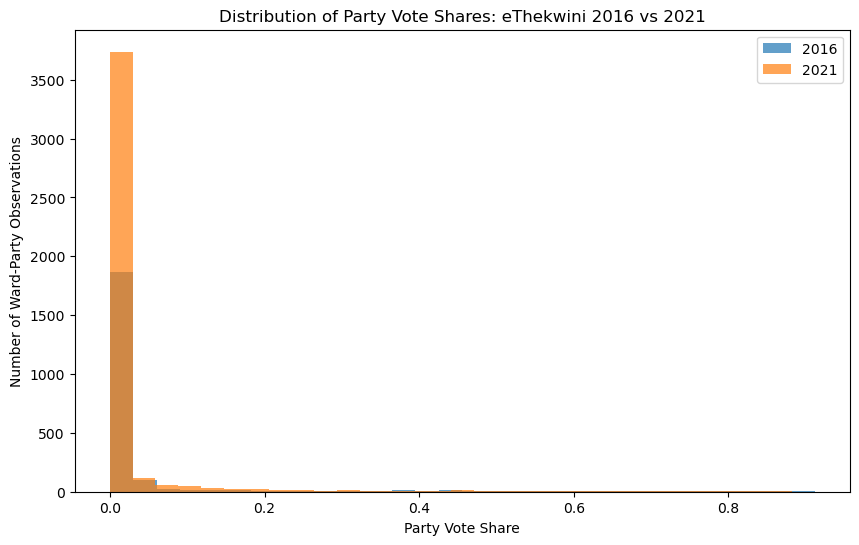

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(ward_2016["VoteShare"], bins=30, alpha=0.7, label="2016")
plt.hist(ward_2021["VoteShare"], bins=30, alpha=0.7, label="2021")

plt.xlabel("Party Vote Share")
plt.ylabel("Number of Ward-Party Observations")
plt.title("Distribution of Party Vote Shares: eThekwini 2016 vs 2021")
plt.legend()
plt.show()

In [32]:
# EDA 2.1 — 2016 vs 2021 party vote share

party_share_2016 = (
    ward_2016.groupby("PartyName")["Votes"]
    .sum()
    .reset_index(name="Votes_2016")
)

party_share_2016["TotalVotes_2016"] = party_share_2016["Votes_2016"].sum()
party_share_2016["VoteShare_2016"] = (
    party_share_2016["Votes_2016"] /
    party_share_2016["TotalVotes_2016"]
)

party_share_2021 = (
    ward_2021.groupby("PartyName")["Votes"]
    .sum()
    .reset_index(name="Votes_2021")
)

party_share_2021["TotalVotes_2021"] = party_share_2021["Votes_2021"].sum()
party_share_2021["VoteShare_2021"] = (
    party_share_2021["Votes_2021"] /
    party_share_2021["TotalVotes_2021"]
)

party_comparison = party_share_2016.merge(
    party_share_2021,
    on="PartyName",
    how="inner"
)

print(party_comparison.sort_values(
    "VoteShare_2021",
    ascending=False
).head(15))


                             PartyName  Votes_2016  TotalVotes_2016  \
4            AFRICAN NATIONAL CONGRESS      593621          1121053   
10                 DEMOCRATIC ALLIANCE      294867          1121053   
12           ECONOMIC FREEDOM FIGHTERS       36552          1121053   
15               INKATHA FREEDOM PARTY       46154          1121053   
13                         INDEPENDENT       93432          1121053   
1   AFRICAN CHRISTIAN DEMOCRATIC PARTY        6147          1121053   
11         DEMOCRATIC LIBERAL CONGRESS        6714          1121053   
17                      MINORITY FRONT        6725          1121053   
16          MINORITIES OF SOUTH AFRICA        3870          1121053   
2         AFRICAN INDEPENDENT CONGRESS       13772          1121053   
21                  VRYHEIDSFRONT PLUS        1122          1121053   
19     PEOPLE'S REVOLUTIONARY MOVEMENT        1053          1121053   
20                      TRULY ALLIANCE        4452          1121053   
6     

In [33]:
# EDA 2.2 — Ward-level relationship between 2016 and 2021

major_parties = [
    "AFRICAN NATIONAL CONGRESS",
    "DEMOCRATIC ALLIANCE",
    "ECONOMIC FREEDOM FIGHTERS",
    "INKATHA FREEDOM PARTY",
    "INDEPENDENT"
]

comparison = ward_2016[
    ward_2016["PartyName"].isin(major_parties)
][["Ward", "PartyName", "VoteShare"]].rename(
    columns={"VoteShare": "VoteShare_2016"}
)

comparison_2021 = ward_2021[
    ward_2021["PartyName"].isin(major_parties)
][["Ward", "PartyName", "VoteShare"]].rename(
    columns={"VoteShare": "VoteShare_2021"}
)

comparison = comparison.merge(
    comparison_2021,
    on=["Ward", "PartyName"],
    how="inner"
)

print("Ward-party observations:", len(comparison))

print("\nCorrelation by party:")

for party in major_parties:
    data = comparison[comparison["PartyName"] == party]

    if len(data) > 1:
        correlation = data["VoteShare_2016"].corr(
            data["VoteShare_2021"]
        )

        print(f"{party}: {correlation:.3f}")

Ward-party observations: 452

Correlation by party:
AFRICAN NATIONAL CONGRESS: 0.804
DEMOCRATIC ALLIANCE: 0.979
ECONOMIC FREEDOM FIGHTERS: 0.485
INKATHA FREEDOM PARTY: 0.907
INDEPENDENT: 0.383


In [34]:
#BIVARIATE ANALYSIS


In [37]:
# EDA 2.3 — Correct 2016 vs 2021 ward turnout

def calculate_ward_turnout(df):

    # Registered voters and spoilt votes: one record per voting district
    electorate = (
        df[["Ward", "VotingDistrict", "RegisteredVoters", "SpoiltVotes"]]
        .drop_duplicates(["Ward", "VotingDistrict"])
        .groupby("Ward", as_index=False)
        .agg(
            RegisteredVoters=("RegisteredVoters", "sum"),
            SpoiltVotes=("SpoiltVotes", "sum")
        )
    )

    # Valid votes: sum all party votes
    valid_votes = (
        df.groupby("Ward", as_index=False)
        .agg(ValidVotes=("TotalValidVotes", "sum"))
    )

    # Combine
    ward_turnout = electorate.merge(
        valid_votes,
        on="Ward",
        how="inner"
    )

    # Turnout
    ward_turnout["TurnoutRate"] = (
        (ward_turnout["ValidVotes"] + ward_turnout["SpoiltVotes"])
        / ward_turnout["RegisteredVoters"]
    )

    return ward_turnout


turnout_2016 = calculate_ward_turnout(df_2016_ward)
turnout_2021 = calculate_ward_turnout(df_2021_ward)

turnout_2016 = turnout_2016[
    ["Ward", "TurnoutRate"]
].rename(columns={"TurnoutRate": "Turnout_2016"})

turnout_2021 = turnout_2021[
    ["Ward", "TurnoutRate"]
].rename(columns={"TurnoutRate": "Turnout_2021"})

turnout_comparison = turnout_2016.merge(
    turnout_2021,
    on="Ward",
    how="inner"
)

print("Comparable wards:", len(turnout_comparison))

correlation = turnout_comparison[
    "Turnout_2016"
].corr(
    turnout_comparison["Turnout_2021"]
)

print("\nTurnout correlation:", round(correlation, 3))

print("\nSummary:")
print(turnout_comparison.describe())

Comparable wards: 110

Turnout correlation: 0.771

Summary:
       Turnout_2016  Turnout_2021
count    110.000000    110.000000
mean       0.593898      0.412586
std        0.059737      0.072477
min        0.392350      0.171406
25%        0.564951      0.371145
50%        0.598348      0.413538
75%        0.632447      0.459480
max        0.756851      0.576248


In [ ]:
#Turnout EDA: Ward-level turnout decreased substantially from 2016 to 2021, with mean turnout falling from approximately 59.4% to 41.3%. However, the 2016 and 2021 ward turnout rates remained strongly positively correlated (r = 0.771), indicating that historical ward-level turnout contains useful information for modelling future turnout. The decline also demonstrates that simply carrying the 2021 turnout rate forward to 2026 would not be sufficiently justified.

In [38]:
# EDA 2.4 — Turnout vs party vote share

# Add turnout to ward-level party data
ward_2016_analysis = ward_2016.merge(
    turnout_2016,
    on="Ward",
    how="left"
)

ward_2021_analysis = ward_2021.merge(
    turnout_2021,
    on="Ward",
    how="left"
)

# Major parties
major_parties = ["ANC", "DA", "EFF", "IFP", "INDEPENDENT"]

for party in major_parties:

    data_2016 = ward_2016_analysis[
        ward_2016_analysis["PartyName"].str.upper() == party
    ]

    data_2021 = ward_2021_analysis[
        ward_2021_analysis["PartyName"].str.upper() == party
    ]

    corr_2016 = data_2016["Turnout_2016"].corr(
        data_2016["VoteShare"]
    )

    corr_2021 = data_2021["Turnout_2021"].corr(
        data_2021["VoteShare"]
    )

    print(f"\n{party}")
    print("2016 turnout vs vote share:", round(corr_2016, 3))
    print("2021 turnout vs vote share:", round(corr_2021, 3))


ANC
2016 turnout vs vote share: nan
2021 turnout vs vote share: nan

DA
2016 turnout vs vote share: nan
2021 turnout vs vote share: nan

EFF
2016 turnout vs vote share: nan
2021 turnout vs vote share: nan

IFP
2016 turnout vs vote share: nan
2021 turnout vs vote share: nan

INDEPENDENT
2016 turnout vs vote share: 0.35
2021 turnout vs vote share: 0.22


In [39]:
print("2016 party names:")
print(
    ward_2016["PartyName"]
    .drop_duplicates()
    .sort_values()
    .to_list()
)

print("\n2021 party names:")
print(
    ward_2021["PartyName"]
    .drop_duplicates()
    .sort_values()
    .to_list()
)

2016 party names:
['ACADEMIC CONGRESS UNION', 'AFRICAN CHRISTIAN DEMOCRATIC PARTY', 'AFRICAN INDEPENDENT CONGRESS', 'AFRICAN MANTUNGWA COMMUNITY', 'AFRICAN NATIONAL CONGRESS', "AFRICAN PEOPLE'S CONVENTION", 'AL JAMA-AH', 'ALLIED MOVEMENT FOR CHANGE', "AZANIAN PEOPLE'S ORGANISATION", 'CONGRESS  OF THE PEOPLE', 'DEMOCRATIC ALLIANCE', 'DEMOCRATIC LIBERAL CONGRESS', 'ECONOMIC FREEDOM FIGHTERS', 'INDEPENDENT', "INDEPENDENT PEOPLE'S PARTY", 'INDEPENDENT RATEPAYERS ASSOCIATION OF SA', 'INKATHA FREEDOM PARTY', 'MINORITIES OF SOUTH AFRICA', 'MINORITY FRONT', 'PAN AFRICANIST CONGRESS OF AZANIA', "PEOPLE'S REVOLUTIONARY MOVEMENT", 'SOUTH AFRICAN POLITICAL PARTY', 'THE PROMISE OF FREEDOM', 'TRULY ALLIANCE', 'UNITED DEMOCRATIC MOVEMENT', 'UNITED PEOPLES PARTY', 'UNITED RESIDENTS FRONT', 'VRYHEIDSFRONT PLUS']

2021 party names:
['ABANTU BATHO CONGRESS', 'ACADEMIC CONGRESS UNION', 'ACTIONSA', 'ACTIVE CITIZENS COALITION', 'ACTIVISTS MOVEMENT OF SOUTH AFRICA', 'ADVANCED DYNAMIC ALLIANCE', 'AFRICA RESTO

In [40]:
# EDA 2.4 — Turnout vs party vote share

party_names = {
    "ANC": "AFRICAN NATIONAL CONGRESS",
    "DA": "DEMOCRATIC ALLIANCE",
    "EFF": "ECONOMIC FREEDOM FIGHTERS",
    "IFP": "INKATHA FREEDOM PARTY",
    "INDEPENDENT": "INDEPENDENT"
}

for label, party_name in party_names.items():

    data_2016 = ward_2016_analysis[
        ward_2016_analysis["PartyName"] == party_name
    ]

    data_2021 = ward_2021_analysis[
        ward_2021_analysis["PartyName"] == party_name
    ]

    corr_2016 = data_2016["Turnout_2016"].corr(
        data_2016["VoteShare"]
    )

    corr_2021 = data_2021["Turnout_2021"].corr(
        data_2021["VoteShare"]
    )

    print(f"\n{label}")
    print("2016 turnout vs vote share:", round(corr_2016, 3))
    print("2021 turnout vs vote share:", round(corr_2021, 3))


ANC
2016 turnout vs vote share: -0.12
2021 turnout vs vote share: -0.367

DA
2016 turnout vs vote share: 0.14
2021 turnout vs vote share: 0.5

EFF
2016 turnout vs vote share: -0.362
2021 turnout vs vote share: -0.61

IFP
2016 turnout vs vote share: -0.387
2021 turnout vs vote share: -0.371

INDEPENDENT
2016 turnout vs vote share: 0.35
2021 turnout vs vote share: 0.22


In [41]:
# Multivariate EDA 3.1 — Correlation matrix

# Create ward-level summary data
ward_summary_2016 = (
    ward_2016_analysis
    .groupby("Ward", as_index=False)
    .agg(
        RegisteredVoters=("RegisteredVoters", "first"),
        SpoiltVotes=("SpoiltVotes", "first"),
        WardValidVotes=("WardValidVotes", "first"),
        Turnout=("Turnout_2016", "first")
    )
)

ward_summary_2021 = (
    ward_2021_analysis
    .groupby("Ward", as_index=False)
    .agg(
        RegisteredVoters=("RegisteredVoters", "first"),
        SpoiltVotes=("SpoiltVotes", "first"),
        WardValidVotes=("WardValidVotes", "first"),
        Turnout=("Turnout_2021", "first")
    )
)

# Rename columns
ward_summary_2016 = ward_summary_2016.rename(
    columns={
        "RegisteredVoters": "RegisteredVoters_2016",
        "SpoiltVotes": "SpoiltVotes_2016",
        "WardValidVotes": "ValidVotes_2016",
        "Turnout": "Turnout_2016"
    }
)

ward_summary_2021 = ward_summary_2021.rename(
    columns={
        "RegisteredVoters": "RegisteredVoters_2021",
        "SpoiltVotes": "SpoiltVotes_2021",
        "WardValidVotes": "ValidVotes_2021",
        "Turnout": "Turnout_2021"
    }
)

# Merge comparable wards
multivariate_data = ward_summary_2016.merge(
    ward_summary_2021,
    on="Ward",
    how="inner"
)

# Display correlations
correlation_matrix = multivariate_data.corr(
    numeric_only=True
)

print("Correlation Matrix:")
print(correlation_matrix.round(3))

Correlation Matrix:
                       RegisteredVoters_2016  SpoiltVotes_2016  \
RegisteredVoters_2016                  1.000             0.078   
SpoiltVotes_2016                       0.078             1.000   
ValidVotes_2016                        0.759             0.227   
Turnout_2016                           0.106             0.349   
RegisteredVoters_2021                  0.545             0.045   
SpoiltVotes_2021                       0.015             0.520   
ValidVotes_2021                        0.444             0.086   
Turnout_2021                           0.256             0.119   

                       ValidVotes_2016  Turnout_2016  RegisteredVoters_2021  \
RegisteredVoters_2016            0.759         0.106                  0.545   
SpoiltVotes_2016                 0.227         0.349                  0.045   
ValidVotes_2016                  1.000         0.722                  0.559   
Turnout_2016                     0.722         1.000                 

In [ ]:
#The multivariate analysis identified strong temporal relationships between corresponding ward-level measures across elections, particularly turnout (r = 0.771) and valid votes (r = 0.786). However, the very strong relationship between 2021 valid votes and 2021 turnout (r = 0.895) reflects their mathematical relationship and therefore these variables should not be treated as independent predictors without careful feature construction. This supports using historical turnout and party vote-share information while avoiding variables that directly reproduce the prediction target.

In [42]:
# Multivariate EDA 3.2 — Party vote-share relationships

# Keep major parties
major_party_names = {
    "ANC": "AFRICAN NATIONAL CONGRESS",
    "DA": "DEMOCRATIC ALLIANCE",
    "EFF": "ECONOMIC FREEDOM FIGHTERS",
    "IFP": "INKATHA FREEDOM PARTY",
    "INDEPENDENT": "INDEPENDENT"
}

# Create 2016 party-share table
party_share_2016 = ward_2016[
    ward_2016["PartyName"].isin(major_party_names.values())
].pivot(
    index="Ward",
    columns="PartyName",
    values="VoteShare"
).rename(
    columns={v: k for k, v in major_party_names.items()}
)

# Create 2021 party-share table
party_share_2021 = ward_2021[
    ward_2021["PartyName"].isin(major_party_names.values())
].pivot(
    index="Ward",
    columns="PartyName",
    values="VoteShare"
).rename(
    columns={v: k for k, v in major_party_names.items()}
)

# Combine comparable wards
party_multivariate = party_share_2016.add_suffix("_2016").join(
    party_share_2021.add_suffix("_2021"),
    how="inner"
)

print("Comparable wards:", len(party_multivariate))

print("\nCorrelation matrix:")
print(
    party_multivariate.corr().round(3)
)

Comparable wards: 110

Correlation matrix:
PartyName         ANC_2016  DA_2016  EFF_2016  INDEPENDENT_2016  IFP_2016  \
PartyName                                                                   
ANC_2016             1.000   -0.851     0.427            -0.247     0.080   
DA_2016             -0.851    1.000    -0.381            -0.509    -0.295   
EFF_2016             0.427   -0.381     1.000            -0.319     0.163   
INDEPENDENT_2016    -0.247   -0.509    -0.319             1.000    -0.190   
IFP_2016             0.080   -0.295     0.163            -0.190     1.000   
ANC_2021             0.804   -0.875     0.252             0.490     0.008   
DA_2021             -0.837    0.979    -0.376            -0.459    -0.295   
EFF_2021             0.731   -0.725     0.485             0.064     0.081   
INDEPENDENT_2021    -0.027   -0.161     0.124             0.383    -0.040   
IFP_2021             0.145   -0.347     0.098            -0.176     0.907   

PartyName         ANC_2021  DA_2

In [ ]:
#SPATIAL ANALYSIS

In [43]:
# Spatial EDA 4.1 — Voting-district stability between 2016 and 2021

vd_2016 = (
    df_2016_ward
    .groupby("Ward")["VotingDistrict"]
    .apply(set)
)

vd_2021 = (
    df_2021_ward
    .groupby("Ward")["VotingDistrict"]
    .apply(set)
)

common_wards = sorted(
    set(vd_2016.index).intersection(vd_2021.index)
)

stable_wards = []

for ward in common_wards:
    if vd_2016[ward] == vd_2021[ward]:
        stable_wards.append(ward)

print("Common wards:", len(common_wards))
print("Geographically stable wards:", len(stable_wards))

print("\nStable wards:")
print(stable_wards)

Common wards: 110
Geographically stable wards: 53

Stable wards:
['Ward 59500001', 'Ward 59500004', 'Ward 59500005', 'Ward 59500006', 'Ward 59500012', 'Ward 59500013', 'Ward 59500014', 'Ward 59500015', 'Ward 59500016', 'Ward 59500018', 'Ward 59500020', 'Ward 59500021', 'Ward 59500022', 'Ward 59500024', 'Ward 59500026', 'Ward 59500028', 'Ward 59500032', 'Ward 59500033', 'Ward 59500036', 'Ward 59500037', 'Ward 59500038', 'Ward 59500040', 'Ward 59500041', 'Ward 59500042', 'Ward 59500043', 'Ward 59500044', 'Ward 59500046', 'Ward 59500049', 'Ward 59500055', 'Ward 59500063', 'Ward 59500064', 'Ward 59500065', 'Ward 59500066', 'Ward 59500067', 'Ward 59500068', 'Ward 59500075', 'Ward 59500076', 'Ward 59500080', 'Ward 59500081', 'Ward 59500086', 'Ward 59500087', 'Ward 59500088', 'Ward 59500090', 'Ward 59500091', 'Ward 59500092', 'Ward 59500093', 'Ward 59500094', 'Ward 59500097', 'Ward 59500098', 'Ward 59500101', 'Ward 59500103', 'Ward 59500105', 'Ward 59500109']


In [ ]:
#Spatial comparability: Although 110 ward identifiers were present in both the 2016 and 2021 datasets, only 53 had identical voting-district composition across the two elections. Therefore, ward identifiers alone were not considered sufficient evidence of geographic comparability. The 53 wards with unchanged voting-district composition were retained as the strongest candidates for historical ward-level analysis, while wards with changed composition were treated cautiously.

In [44]:
# Spatial EDA 4.2 — Profile geographically stable wards

# Filter to geographically stable wards
stable_2016 = ward_2016_analysis[
    ward_2016_analysis["Ward"].isin(stable_wards)
].copy()

stable_2021 = ward_2021_analysis[
    ward_2021_analysis["Ward"].isin(stable_wards)
].copy()


# Find leading party in each ward
leaders_2016 = (
    stable_2016
    .sort_values(["Ward", "VoteShare"], ascending=[True, False])
    .groupby("Ward")
    .first()
    .reset_index()[["Ward", "PartyName", "VoteShare"]]
    .rename(columns={
        "PartyName": "Leader_2016",
        "VoteShare": "LeaderShare_2016"
    })
)

leaders_2021 = (
    stable_2021
    .sort_values(["Ward", "VoteShare"], ascending=[True, False])
    .groupby("Ward")
    .first()
    .reset_index()[["Ward", "PartyName", "VoteShare"]]
    .rename(columns={
        "PartyName": "Leader_2021",
        "VoteShare": "LeaderShare_2021"
    })
)


# Ward-level turnout
turnout_stable = turnout_comparison[
    turnout_comparison["Ward"].isin(stable_wards)
].copy()

turnout_stable["TurnoutChange"] = (
    turnout_stable["Turnout_2021"]
    - turnout_stable["Turnout_2016"]
)


# Combine
stable_profile = (
    turnout_stable
    .merge(leaders_2016, on="Ward")
    .merge(leaders_2021, on="Ward")
)

stable_profile["LeaderChanged"] = (
    stable_profile["Leader_2016"]
    != stable_profile["Leader_2021"]
)

stable_profile["LeaderShareChange"] = (
    stable_profile["LeaderShare_2021"]
    - stable_profile["LeaderShare_2016"]
)


# Show wards where leader stayed the same
stable_profile = stable_profile.sort_values(
    ["LeaderChanged", "Turnout_2021"],
    ascending=[True, False]
)

print(stable_profile[
    [
        "Ward",
        "Turnout_2016",
        "Turnout_2021",
        "TurnoutChange",
        "Leader_2016",
        "Leader_2021",
        "LeaderShare_2016",
        "LeaderShare_2021",
        "LeaderChanged"
    ]
].to_string(index=False))

         Ward  Turnout_2016  Turnout_2021  TurnoutChange               Leader_2016               Leader_2021  LeaderShare_2016  LeaderShare_2021  LeaderChanged
Ward 59500001      0.756851      0.576248      -0.180603 AFRICAN NATIONAL CONGRESS AFRICAN NATIONAL CONGRESS          0.770802          0.881611          False
Ward 59500105      0.617684      0.544578      -0.073105 AFRICAN NATIONAL CONGRESS AFRICAN NATIONAL CONGRESS          0.754214          0.365818          False
Ward 59500036      0.652889      0.521064      -0.131825       DEMOCRATIC ALLIANCE       DEMOCRATIC ALLIANCE          0.849670          0.829073          False
Ward 59500063      0.639692      0.486720      -0.152972       DEMOCRATIC ALLIANCE       DEMOCRATIC ALLIANCE          0.829570          0.771865          False
Ward 59500049      0.580879      0.485033      -0.095846       DEMOCRATIC ALLIANCE       DEMOCRATIC ALLIANCE          0.668229          0.571275          False
Ward 59500097      0.644510      0.47840

In [45]:
# Spatial EDA 4.2 — Profile geographically stable wards

# Filter to geographically stable wards
stable_2016 = ward_2016_analysis[
    ward_2016_analysis["Ward"].isin(stable_wards)
].copy()

stable_2021 = ward_2021_analysis[
    ward_2021_analysis["Ward"].isin(stable_wards)
].copy()


# Find leading party in each ward
leaders_2016 = (
    stable_2016
    .sort_values(["Ward", "VoteShare"], ascending=[True, False])
    .groupby("Ward")
    .first()
    .reset_index()[["Ward", "PartyName", "VoteShare"]]
    .rename(columns={
        "PartyName": "Leader_2016",
        "VoteShare": "LeaderShare_2016"
    })
)

leaders_2021 = (
    stable_2021
    .sort_values(["Ward", "VoteShare"], ascending=[True, False])
    .groupby("Ward")
    .first()
    .reset_index()[["Ward", "PartyName", "VoteShare"]]
    .rename(columns={
        "PartyName": "Leader_2021",
        "VoteShare": "LeaderShare_2021"
    })
)


# Ward-level turnout
turnout_stable = turnout_comparison[
    turnout_comparison["Ward"].isin(stable_wards)
].copy()

turnout_stable["TurnoutChange"] = (
    turnout_stable["Turnout_2021"]
    - turnout_stable["Turnout_2016"]
)


# Combine
stable_profile = (
    turnout_stable
    .merge(leaders_2016, on="Ward")
    .merge(leaders_2021, on="Ward")
)

stable_profile["LeaderChanged"] = (
    stable_profile["Leader_2016"]
    != stable_profile["Leader_2021"]
)

stable_profile["LeaderShareChange"] = (
    stable_profile["LeaderShare_2021"]
    - stable_profile["LeaderShare_2016"]
)


# Show wards where leader stayed the same
stable_profile = stable_profile.sort_values(
    ["LeaderChanged", "Turnout_2021"],
    ascending=[True, False]
)

print(stable_profile[
    [
        "Ward",
        "Turnout_2016",
        "Turnout_2021",
        "TurnoutChange",
        "Leader_2016",
        "Leader_2021",
        "LeaderShare_2016",
        "LeaderShare_2021",
        "LeaderChanged"
    ]
].to_string(index=False))

         Ward  Turnout_2016  Turnout_2021  TurnoutChange               Leader_2016               Leader_2021  LeaderShare_2016  LeaderShare_2021  LeaderChanged
Ward 59500001      0.756851      0.576248      -0.180603 AFRICAN NATIONAL CONGRESS AFRICAN NATIONAL CONGRESS          0.770802          0.881611          False
Ward 59500105      0.617684      0.544578      -0.073105 AFRICAN NATIONAL CONGRESS AFRICAN NATIONAL CONGRESS          0.754214          0.365818          False
Ward 59500036      0.652889      0.521064      -0.131825       DEMOCRATIC ALLIANCE       DEMOCRATIC ALLIANCE          0.849670          0.829073          False
Ward 59500063      0.639692      0.486720      -0.152972       DEMOCRATIC ALLIANCE       DEMOCRATIC ALLIANCE          0.829570          0.771865          False
Ward 59500049      0.580879      0.485033      -0.095846       DEMOCRATIC ALLIANCE       DEMOCRATIC ALLIANCE          0.668229          0.571275          False
Ward 59500097      0.644510      0.47840

In [47]:
# Spatial EDA 4.3 — Remove wards affected by 2026 delimitation

affected_2026 = {
    5, 6, 12, 13, 14, 30, 31, 42, 47,
    52, 53, 54, 55, 56, 57, 72, 74, 75,
    91, 107, 108
}

# Convert ward IDs such as "Ward 59500001" to numeric ward numbers
stable_profile["WardNumber"] = (
    stable_profile["Ward"]
    .str.extract(r"(\d+)$")[0]
    .astype(int)
)

# Keep historically stable wards that are not affected by 2026 delimitation
candidate_wards = stable_profile[
    ~stable_profile["WardNumber"].isin(affected_2026)
].copy()

print("Historically stable wards:", len(stable_profile))
print("Stable wards unaffected by 2026 delimitation:", len(candidate_wards))

print("\nCandidate wards:")
print(
    candidate_wards[
        [
            "Ward",
            "Turnout_2016",
            "Turnout_2021",
            "TurnoutChange",
            "Leader_2016",
            "Leader_2021",
            "LeaderShare_2016",
            "LeaderShare_2021",
            "LeaderChanged"
        ]
    ].to_string(index=False)
)

Historically stable wards: 53
Stable wards unaffected by 2026 delimitation: 53

Candidate wards:
         Ward  Turnout_2016  Turnout_2021  TurnoutChange               Leader_2016               Leader_2021  LeaderShare_2016  LeaderShare_2021  LeaderChanged
Ward 59500001      0.756851      0.576248      -0.180603 AFRICAN NATIONAL CONGRESS AFRICAN NATIONAL CONGRESS          0.770802          0.881611          False
Ward 59500105      0.617684      0.544578      -0.073105 AFRICAN NATIONAL CONGRESS AFRICAN NATIONAL CONGRESS          0.754214          0.365818          False
Ward 59500036      0.652889      0.521064      -0.131825       DEMOCRATIC ALLIANCE       DEMOCRATIC ALLIANCE          0.849670          0.829073          False
Ward 59500063      0.639692      0.486720      -0.152972       DEMOCRATIC ALLIANCE       DEMOCRATIC ALLIANCE          0.829570          0.771865          False
Ward 59500049      0.580879      0.485033      -0.095846       DEMOCRATIC ALLIANCE       DEMOCRATIC ALL

In [ ]:
#FEATURE ENGINEERING

In [49]:

# Build 2016 -> 2021 transition dataset
# ============================================================

# Use only the 53 geographically stable wards
stable_2016 = ward_2016_analysis[
    ward_2016_analysis["Ward"].isin(stable_wards)
].copy()

stable_2021 = ward_2021_analysis[
    ward_2021_analysis["Ward"].isin(stable_wards)
].copy()


# ------------------------------------------------------------
# 1. Create party vote-share features
# ------------------------------------------------------------

major_parties = {
    "ANC": "AFRICAN NATIONAL CONGRESS",
    "DA": "DEMOCRATIC ALLIANCE",
    "EFF": "ECONOMIC FREEDOM FIGHTERS",
    "IFP": "INKATHA FREEDOM PARTY",
    "INDEPENDENT": "INDEPENDENT"
}

party_features_2016 = stable_2016[
    stable_2016["PartyName"].isin(major_parties.values())
].pivot(
    index="Ward",
    columns="PartyName",
    values="VoteShare"
).rename(
    columns={v: k for k, v in major_parties.items()}
)

party_outcomes_2021 = stable_2021[
    stable_2021["PartyName"].isin(major_parties.values())
].pivot(
    index="Ward",
    columns="PartyName",
    values="VoteShare"
).rename(
    columns={v: k for k, v in major_parties.items()}
)


# ------------------------------------------------------------
# 2. Create electorate and turnout features
# ------------------------------------------------------------

features_2016 = (
    turnout_2016[
        turnout_2016["Ward"].isin(stable_wards)
    ]
    .set_index("Ward")
    .rename(columns={
        "Turnout_2016": "Turnout_2016"
    })
)

# ------------------------------------------------------------
# 2. Create electorate feature correctly
# ------------------------------------------------------------

registered_2016 = (
    df_2016_ward[
        df_2016_ward["Ward"].isin(stable_wards)
    ][["Ward", "VotingDistrict", "RegisteredVoters"]]
    .drop_duplicates(["Ward", "VotingDistrict"])
    .groupby("Ward", as_index=True)
    ["RegisteredVoters"]
    .sum()
    .rename("RegisteredVoters_2016")
)

print(registered_2016.head())

# ------------------------------------------------------------
# 3. Combine 2016 features
# ------------------------------------------------------------

transition_features = (
    party_features_2016
    .join(features_2016)
    .join(registered_2016)
)


# ------------------------------------------------------------
# 4. Add 2021 target variables
# ------------------------------------------------------------

targets_2021 = party_outcomes_2021.add_suffix("_2021")

transition_data = transition_features.join(
    targets_2021,
    how="inner"
)


# ------------------------------------------------------------
# 5. Add 2021 turnout as a target
# ------------------------------------------------------------

turnout_target = (
    turnout_2021[
        turnout_2021["Ward"].isin(stable_wards)
    ]
    .set_index("Ward")
)

transition_data = transition_data.join(
    turnout_target[["Turnout_2021"]]
)


# ------------------------------------------------------------
# 6. Reset index
# ------------------------------------------------------------

transition_data = transition_data.reset_index()


# ------------------------------------------------------------
# 7. Inspect the dataset
# ------------------------------------------------------------

print("Transition dataset shape:", transition_data.shape)

print("\nColumns:")
print(transition_data.columns.tolist())

print("\nMissing values:")
print(transition_data.isna().sum())

print("\nFirst 10 rows:")
display(transition_data.head(10))

Ward
Ward 59500001    17187
Ward 59500004    19368
Ward 59500005    15202
Ward 59500006    18013
Ward 59500012    17139
Name: RegisteredVoters_2016, dtype: int64
Transition dataset shape: (53, 14)

Columns:
['Ward', 'ANC', 'DA', 'EFF', 'INDEPENDENT', 'IFP', 'Turnout_2016', 'RegisteredVoters_2016', 'ANC_2021', 'DA_2021', 'EFF_2021', 'INDEPENDENT_2021', 'IFP_2021', 'Turnout_2021']

Missing values:
Ward                      0
ANC                       0
DA                        0
EFF                       2
INDEPENDENT              30
IFP                       4
Turnout_2016              0
RegisteredVoters_2016     0
ANC_2021                  0
DA_2021                   0
EFF_2021                  0
INDEPENDENT_2021         35
IFP_2021                  0
Turnout_2021              0
dtype: int64

First 10 rows:


,Ward,ANC,DA,EFF,INDEPENDENT,IFP,Turnout_2016,RegisteredVoters_2016,ANC_2021,DA_2021,EFF_2021,INDEPENDENT_2021,IFP_2021,Turnout_2021
0,Ward 59500001,0.770802,0.025081,0.003549,0.175803,0.003076,0.756851,17187,0.881611,0.016087,0.047683,NaN,0.004239,0.576248
1,Ward 59500004,0.290330,0.030481,0.005889,0.649980,0.005412,0.670591,19368,0.806776,0.031075,0.074766,NaN,0.017757,0.443922
2,Ward 59500005,0.810672,0.007162,0.015130,0.137482,0.011297,0.667675,15202,0.569744,0.004560,0.259947,0.099229,0.033339,0.448477
3,Ward 59500006,0.827479,0.021659,0.033336,NaN,0.096337,0.598568,18013,0.679486,0.006045,0.170804,NaN,0.088617,0.444708
4,Ward 59500012,0.437962,0.012283,0.022455,0.490452,0.016697,0.618297,17139,0.650431,0.012177,0.186369,NaN,0.046169,0.366733
5,Ward 59500013,0.691919,0.188959,0.036156,NaN,0.017325,0.591848,15923,0.474138,0.165285,0.093667,0.139920,0.035312,0.409655
6,Ward 59500014,0.567766,0.029397,0.038626,0.321398,0.017006,0.621313,19425,0.676975,0.032258,0.125629,NaN,0.040693,0.377417
7,Ward 59500015,0.519055,0.039051,0.022302,0.388539,0.014585,0.572550,19497,0.640538,0.033735,0.101904,NaN,0.036394,0.384644
8,Ward 59500016,0.485081,0.264544,0.039090,0.184281,NaN,0.632544,19469,0.478953,0.249475,0.122824,NaN,0.033946,0.418719
9,Ward 59500018,0.182131,0.777459,0.016066,NaN,NaN,0.637613,19286,0.101457,0.743762,0.026496,NaN,0.017443,0.475775


In [50]:
# ============================================================
# FEATURE ENGINEERING 5.1 — CLEAN TRANSITION DATA
# ============================================================

# Party share NaN means the party had no recorded votes
# in that ward, so replace with 0.
party_columns = [
    "ANC",
    "DA",
    "EFF",
    "INDEPENDENT",
    "IFP",
    "ANC_2021",
    "DA_2021",
    "EFF_2021",
    "INDEPENDENT_2021",
    "IFP_2021"
]

transition_data[party_columns] = transition_data[party_columns].fillna(0)


# Check missing values
print("Missing values after party-share cleanup:")
print(transition_data.isna().sum())


# Check that each year's selected party shares are sensible
print("\n2016 selected-party share totals:")
print(
    transition_data[
        ["ANC", "DA", "EFF", "INDEPENDENT", "IFP"]
    ].sum(axis=1).describe()
)

print("\n2021 selected-party share totals:")
print(
    transition_data[
        ["ANC_2021", "DA_2021", "EFF_2021", "INDEPENDENT_2021", "IFP_2021"]
    ].sum(axis=1).describe()
)

print("\nFinal shape:", transition_data.shape)

display(transition_data.head(10))

Missing values after party-share cleanup:
Ward                     0
ANC                      0
DA                       0
EFF                      0
INDEPENDENT              0
IFP                      0
Turnout_2016             0
RegisteredVoters_2016    0
ANC_2021                 0
DA_2021                  0
EFF_2021                 0
INDEPENDENT_2021         0
IFP_2021                 0
Turnout_2021             0
dtype: int64

2016 selected-party share totals:
count    53.000000
mean      0.961696
std       0.025096
min       0.838536
25%       0.953373
50%       0.968182
75%       0.976842
max       0.984230
dtype: float64

2021 selected-party share totals:
count    53.000000
mean      0.894386
std       0.075171
min       0.516383
25%       0.889159
50%       0.916930
75%       0.930374
max       0.966819
dtype: float64

Final shape: (53, 14)


,Ward,ANC,DA,EFF,INDEPENDENT,IFP,Turnout_2016,RegisteredVoters_2016,ANC_2021,DA_2021,EFF_2021,INDEPENDENT_2021,IFP_2021,Turnout_2021
0,Ward 59500001,0.770802,0.025081,0.003549,0.175803,0.003076,0.756851,17187,0.881611,0.016087,0.047683,0.000000,0.004239,0.576248
1,Ward 59500004,0.290330,0.030481,0.005889,0.649980,0.005412,0.670591,19368,0.806776,0.031075,0.074766,0.000000,0.017757,0.443922
2,Ward 59500005,0.810672,0.007162,0.015130,0.137482,0.011297,0.667675,15202,0.569744,0.004560,0.259947,0.099229,0.033339,0.448477
3,Ward 59500006,0.827479,0.021659,0.033336,0.000000,0.096337,0.598568,18013,0.679486,0.006045,0.170804,0.000000,0.088617,0.444708
4,Ward 59500012,0.437962,0.012283,0.022455,0.490452,0.016697,0.618297,17139,0.650431,0.012177,0.186369,0.000000,0.046169,0.366733
5,Ward 59500013,0.691919,0.188959,0.036156,0.000000,0.017325,0.591848,15923,0.474138,0.165285,0.093667,0.139920,0.035312,0.409655
6,Ward 59500014,0.567766,0.029397,0.038626,0.321398,0.017006,0.621313,19425,0.676975,0.032258,0.125629,0.000000,0.040693,0.377417
7,Ward 59500015,0.519055,0.039051,0.022302,0.388539,0.014585,0.572550,19497,0.640538,0.033735,0.101904,0.000000,0.036394,0.384644
8,Ward 59500016,0.485081,0.264544,0.039090,0.184281,0.000000,0.632544,19469,0.478953,0.249475,0.122824,0.000000,0.033946,0.418719
9,Ward 59500018,0.182131,0.777459,0.016066,0.000000,0.000000,0.637613,19286,0.101457,0.743762,0.026496,0.000000,0.017443,0.475775


In [51]:
# ============================================================
# FEATURE ENGINEERING 5.2
# Create historical change / trend features
# ============================================================

# ------------------------------------------------------------
# 1. Calculate party vote-share changes: 2016 -> 2021
# ------------------------------------------------------------

transition_data["ANC_Change"] = (
    transition_data["ANC_2021"] - transition_data["ANC"]
)

transition_data["DA_Change"] = (
    transition_data["DA_2021"] - transition_data["DA"]
)

transition_data["EFF_Change"] = (
    transition_data["EFF_2021"] - transition_data["EFF"]
)

transition_data["INDEPENDENT_Change"] = (
    transition_data["INDEPENDENT_2021"] - transition_data["INDEPENDENT"]
)

transition_data["IFP_Change"] = (
    transition_data["IFP_2021"] - transition_data["IFP"]
)


# ------------------------------------------------------------
# 2. Calculate turnout change
# ------------------------------------------------------------

transition_data["Turnout_Change"] = (
    transition_data["Turnout_2021"]
    - transition_data["Turnout_2016"]
)


# ------------------------------------------------------------
# 3. Calculate registered-voter growth
# ------------------------------------------------------------

# We need 2021 registered voters first
registered_2021 = (
    df_2021_ward[
        df_2021_ward["Ward"].isin(stable_wards)
    ][["Ward", "VotingDistrict", "RegisteredVoters"]]
    .drop_duplicates(["Ward", "VotingDistrict"])
    .groupby("Ward")["RegisteredVoters"]
    .sum()
    .rename("RegisteredVoters_2021")
)

transition_data = transition_data.set_index("Ward")

transition_data = transition_data.join(
    registered_2021,
    how="left"
)

transition_data = transition_data.reset_index()


# ------------------------------------------------------------
# 4. Calculate electorate growth rate
# ------------------------------------------------------------

transition_data["RegisteredVoters_Change"] = (
    transition_data["RegisteredVoters_2021"]
    - transition_data["RegisteredVoters_2016"]
)

transition_data["RegisteredVoters_GrowthRate"] = (
    transition_data["RegisteredVoters_Change"]
    / transition_data["RegisteredVoters_2016"]
)


# ------------------------------------------------------------
# 5. Inspect the new features
# ------------------------------------------------------------

change_columns = [
    "Ward",
    "ANC_Change",
    "DA_Change",
    "EFF_Change",
    "INDEPENDENT_Change",
    "IFP_Change",
    "Turnout_Change",
    "RegisteredVoters_Change",
    "RegisteredVoters_GrowthRate"
]

display(
    transition_data[change_columns].head(10)
)

print("\nSummary statistics:")
display(
    transition_data[
        [
            "ANC_Change",
            "DA_Change",
            "EFF_Change",
            "INDEPENDENT_Change",
            "IFP_Change",
            "Turnout_Change",
            "RegisteredVoters_GrowthRate"
        ]
    ].describe()
)

,Ward,ANC_Change,DA_Change,EFF_Change,INDEPENDENT_Change,IFP_Change,Turnout_Change,RegisteredVoters_Change,RegisteredVoters_GrowthRate
0,Ward 59500001,0.110809,-0.008994,0.044134,-0.175803,0.001163,-0.180603,1102,0.064118
1,Ward 59500004,0.516445,0.000593,0.068877,-0.649980,0.012345,-0.226669,408,0.021066
2,Ward 59500005,-0.240928,-0.002601,0.244816,-0.038253,0.022041,-0.219199,-597,-0.039271
3,Ward 59500006,-0.147994,-0.015614,0.137467,0.000000,-0.007719,-0.153859,91,0.005052
4,Ward 59500012,0.212469,-0.000106,0.163914,-0.490452,0.029472,-0.251564,-672,-0.039209
5,Ward 59500013,-0.217781,-0.023674,0.057511,0.139920,0.017987,-0.182193,-864,-0.054261
6,Ward 59500014,0.109209,0.002861,0.087003,-0.321398,0.023687,-0.243895,-862,-0.044376
7,Ward 59500015,0.121482,-0.005317,0.079602,-0.388539,0.021809,-0.187906,-391,-0.020054
8,Ward 59500016,-0.006128,-0.015069,0.083734,-0.184281,0.033946,-0.213825,62,0.003185
9,Ward 59500018,-0.080674,-0.033697,0.010430,0.000000,0.017443,-0.161837,-132,-0.006844



Summary statistics:


,ANC_Change,DA_Change,EFF_Change,INDEPENDENT_Change,IFP_Change,Turnout_Change,RegisteredVoters_GrowthRate
count,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000
mean,-0.096417,-0.018811,0.086833,-0.066114,0.027200,-0.190225,-0.016777
std,0.153536,0.049395,0.062254,0.157480,0.028855,0.042082,0.028775
min,-0.389011,-0.318246,-0.019253,-0.649980,-0.042476,-0.271279,-0.071506
25%,-0.192520,-0.020238,0.044134,-0.143584,0.011427,-0.218266,-0.039271
50%,-0.104493,-0.009779,0.078758,0.000000,0.022844,-0.190825,-0.020810
75%,-0.027285,-0.002334,0.127733,0.000000,0.034708,-0.163650,0.003185
max,0.516445,0.064654,0.244816,0.276002,0.130698,-0.073105,0.064118


In [52]:
# ============================================================
# FEATURE ENGINEERING 5.3
# Define modelling features and check for leakage
# ============================================================

# ------------------------------------------------------------
# Features available before the 2021 election
# ------------------------------------------------------------

base_features = [
    "ANC",
    "DA",
    "EFF",
    "INDEPENDENT",
    "IFP",
    "Turnout_2016",
    "RegisteredVoters_2016"
]


# ------------------------------------------------------------
# Historical change variables
# These are NOT direct 2026 predictors.
# They are retained for historical analysis only.
# ------------------------------------------------------------

historical_change_features = [
    "ANC_Change",
    "DA_Change",
    "EFF_Change",
    "INDEPENDENT_Change",
    "IFP_Change",
    "Turnout_Change",
    "RegisteredVoters_GrowthRate"
]


# ------------------------------------------------------------
# 2021 target variables
# ------------------------------------------------------------

party_targets = [
    "ANC_2021",
    "DA_2021",
    "EFF_2021",
    "INDEPENDENT_2021",
    "IFP_2021"
]

turnout_target = "Turnout_2021"


# ------------------------------------------------------------
# Display the modelling structure
# ------------------------------------------------------------

print("BASE FEATURES:")
for feature in base_features:
    print(" -", feature)

print("\nHISTORICAL CHANGE FEATURES:")
for feature in historical_change_features:
    print(" -", feature)

print("\nPARTY TARGETS:")
for target in party_targets:
    print(" -", target)

print("\nTURNOUT TARGET:")
print(" -", turnout_target)


# ------------------------------------------------------------
# Check that target variables are NOT in base features
# ------------------------------------------------------------

leakage_check = set(base_features).intersection(
    set(party_targets + [turnout_target])
)

print("\nDirect target leakage:", leakage_check)


# ------------------------------------------------------------
# Create the historical modelling dataset
# ------------------------------------------------------------

model_data = transition_data[
    ["Ward"] + base_features + party_targets + [turnout_target]
].copy()

print("\nModel dataset shape:", model_data.shape)

print("\nMissing values:")
print(model_data.isna().sum())

display(model_data.head())

BASE FEATURES:
 - ANC
 - DA
 - EFF
 - INDEPENDENT
 - IFP
 - Turnout_2016
 - RegisteredVoters_2016

HISTORICAL CHANGE FEATURES:
 - ANC_Change
 - DA_Change
 - EFF_Change
 - INDEPENDENT_Change
 - IFP_Change
 - Turnout_Change
 - RegisteredVoters_GrowthRate

PARTY TARGETS:
 - ANC_2021
 - DA_2021
 - EFF_2021
 - INDEPENDENT_2021
 - IFP_2021

TURNOUT TARGET:
 - Turnout_2021

Direct target leakage: set()

Model dataset shape: (53, 14)

Missing values:
Ward                     0
ANC                      0
DA                       0
EFF                      0
INDEPENDENT              0
IFP                      0
Turnout_2016             0
RegisteredVoters_2016    0
ANC_2021                 0
DA_2021                  0
EFF_2021                 0
INDEPENDENT_2021         0
IFP_2021                 0
Turnout_2021             0
dtype: int64


,Ward,ANC,DA,EFF,INDEPENDENT,IFP,Turnout_2016,RegisteredVoters_2016,ANC_2021,DA_2021,EFF_2021,INDEPENDENT_2021,IFP_2021,Turnout_2021
0,Ward 59500001,0.770802,0.025081,0.003549,0.175803,0.003076,0.756851,17187,0.881611,0.016087,0.047683,0.000000,0.004239,0.576248
1,Ward 59500004,0.290330,0.030481,0.005889,0.649980,0.005412,0.670591,19368,0.806776,0.031075,0.074766,0.000000,0.017757,0.443922
2,Ward 59500005,0.810672,0.007162,0.015130,0.137482,0.011297,0.667675,15202,0.569744,0.004560,0.259947,0.099229,0.033339,0.448477
3,Ward 59500006,0.827479,0.021659,0.033336,0.000000,0.096337,0.598568,18013,0.679486,0.006045,0.170804,0.000000,0.088617,0.444708
4,Ward 59500012,0.437962,0.012283,0.022455,0.490452,0.016697,0.618297,17139,0.650431,0.012177,0.186369,0.000000,0.046169,0.366733


In [53]:
# ==========================================
# FEATURE ENGINEERING AUDIT
# ==========================================

print("MODEL DATA SHAPE:")
print(model_data.shape)

print("\nMODEL DATA COLUMNS:")
print(model_data.columns.tolist())

print("\nMISSING VALUES:")
print(model_data.isnull().sum())

print("\nDUPLICATE ROWS:")
print(model_data.duplicated().sum())

print("\nFEATURE SUMMARY:")
display(
    model_data[
        [
            "ANC",
            "DA",
            "EFF",
            "INDEPENDENT",
            "IFP",
            "Turnout_2016",
            "RegisteredVoters_2016"
        ]
    ].describe().T
)

MODEL DATA SHAPE:
(53, 14)

MODEL DATA COLUMNS:
['Ward', 'ANC', 'DA', 'EFF', 'INDEPENDENT', 'IFP', 'Turnout_2016', 'RegisteredVoters_2016', 'ANC_2021', 'DA_2021', 'EFF_2021', 'INDEPENDENT_2021', 'IFP_2021', 'Turnout_2021']

MISSING VALUES:
Ward                     0
ANC                      0
DA                       0
EFF                      0
INDEPENDENT              0
IFP                      0
Turnout_2016             0
RegisteredVoters_2016    0
ANC_2021                 0
DA_2021                  0
EFF_2021                 0
INDEPENDENT_2021         0
IFP_2021                 0
Turnout_2021             0
dtype: int64

DUPLICATE ROWS:
0

FEATURE SUMMARY:


,count,mean,std,min,25%,50%,75%,max
ANC,53.0,0.567632,0.232760,0.110801,0.453720,0.634873,0.757718,0.897188
DA,53.0,0.218106,0.276375,0.007162,0.019753,0.037023,0.311753,0.849670
EFF,53.0,0.033229,0.026838,0.000000,0.015675,0.026281,0.040397,0.154642
INDEPENDENT,53.0,0.099054,0.151810,0.000000,0.000000,0.000000,0.184281,0.649980
IFP,53.0,0.043674,0.045759,0.000000,0.011504,0.029920,0.062677,0.218511
Turnout_2016,53.0,0.587447,0.069182,0.392350,0.565817,0.604828,0.627768,0.756851
RegisteredVoters_2016,53.0,17214.943396,1719.583150,13089.000000,15894.000000,17139.000000,18855.000000,19821.000000


In [54]:
# FINAL FEATURE VALIDATION
# ==========================================

# 1. Check that every ward has exactly one feature row
print("Unique wards:", model_data["Ward"].nunique())
print("Rows:", len(model_data))

# 2. Check party shares are valid proportions
party_features = ["ANC", "DA", "EFF", "INDEPENDENT", "IFP"]

print("\nPARTY SHARE RANGE CHECK")
for party in party_features:
    print(
        f"{party}: "
        f"min={model_data[party].min():.4f}, "
        f"max={model_data[party].max():.4f}"
    )

# 3. Check turnout is a valid proportion
print("\nTURNOUT RANGE:")
print(
    f"min={model_data['Turnout_2016'].min():.4f}, "
    f"max={model_data['Turnout_2016'].max():.4f}"
)

# 4. Check registered voters are positive integers
print("\nREGISTERED VOTERS CHECK")
print("Minimum:", model_data["RegisteredVoters_2016"].min())
print("Maximum:", model_data["RegisteredVoters_2016"].max())
print(
    "All positive:",
    (model_data["RegisteredVoters_2016"] > 0).all()
)

# 5. Check selected party shares do not exceed 100%
selected_share = model_data[party_features].sum(axis=1)

print("\nSELECTED PARTY SHARE CHECK")
print("Minimum total:", selected_share.min())
print("Maximum total:", selected_share.max())
print(
    "Any total > 100%:",
    (selected_share > 1).any()
)

Unique wards: 53
Rows: 53

PARTY SHARE RANGE CHECK
ANC: min=0.1108, max=0.8972
DA: min=0.0072, max=0.8497
EFF: min=0.0000, max=0.1546
INDEPENDENT: min=0.0000, max=0.6500
IFP: min=0.0000, max=0.2185

TURNOUT RANGE:
min=0.3924, max=0.7569

REGISTERED VOTERS CHECK
Minimum: 13089
Maximum: 19821
All positive: True

SELECTED PARTY SHARE CHECK
Minimum total: 0.8385356795472633
Maximum total: 0.9842297650130548
Any total > 100%: False


In [ ]:
#MACHINE LEARNING MODEL

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

baseline_results = []

for party in ["ANC", "DA", "EFF", "INDEPENDENT", "IFP"]:
    actual = model_data[f"{party}_2021"]
    predicted = model_data[party]

    baseline_results.append({
        "Target": party,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted)
    })

actual = model_data["Turnout_2021"]
predicted = model_data["Turnout_2016"]

baseline_results.append({
    "Target": "Turnout",
    "MAE": mean_absolute_error(actual, predicted),
    "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
    "R2": r2_score(actual, predicted)
})

baseline_results = pd.DataFrame(baseline_results)

print("BASELINE PERFORMANCE")

display(
    baseline_results.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}"
    })
)

BASELINE PERFORMANCE


,Target,MAE,RMSE,R2
0,ANC,0.1462,0.1801,0.3014
1,DA,0.0257,0.0524,0.9594
2,EFF,0.0877,0.1065,-1.1698
3,INDEPENDENT,0.0990,0.1694,-3.8923
4,IFP,0.0297,0.0395,0.5581
5,Turnout,0.1902,0.1947,-5.4912


In [56]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

features = [
    "ANC",
    "DA",
    "EFF",
    "INDEPENDENT",
    "IFP",
    "Turnout_2016",
    "RegisteredVoters_2016"
]

targets = [
    "ANC_2021",
    "DA_2021",
    "EFF_2021",
    "INDEPENDENT_2021",
    "IFP_2021",
    "Turnout_2021"
]

X = model_data[features]

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for target in targets:

    y = model_data[target]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=kf,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        }
    )

    results.append({
        "Target": target.replace("_2021", ""),
        "MAE": -scores["test_MAE"].mean(),
        "RMSE": -scores["test_RMSE"].mean(),
        "R2": scores["test_R2"].mean()
    })

linear_results = pd.DataFrame(results)

print("LINEAR REGRESSION — 5-FOLD CROSS-VALIDATION")

display(
    linear_results.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}"
    })
)

LINEAR REGRESSION — 5-FOLD CROSS-VALIDATION


,Target,MAE,RMSE,R2
0,ANC,0.0692,0.0968,0.7231
1,DA,0.0320,0.0480,0.8605
2,EFF,0.0375,0.0478,0.4932
3,INDEPENDENT,0.0546,0.0838,-0.2376
4,IFP,0.0200,0.0283,0.7063
5,Turnout,0.0293,0.0368,0.6852


In [ ]:
#Because the modelling dataset contains only 53 geographically stable wards, a conventional single 80/20 split would produce a very small and potentially unstable test set. Therefore, 5-fold cross-validation was used to obtain a more reliable estimate of generalisation performance.

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

final_models = {}
predictions_2026 = {}

for target in targets:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression())
    ])

    model.fit(X, model_data[target])

    final_models[target] = model

In [60]:
# Prepare 2021 ward-level features for 2026 projection

projection_2026 = ward_2021[
    ward_2021["Ward"].isin(stable_wards)
].copy()

# Convert 2021 ward data from long format to party-share features
projection_party = (
    projection_2026
    .pivot_table(
        index="Ward",
        columns="PartyName",
        values="VoteShare",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

# Keep only the parties used by our model
for party in ["ANC", "DA", "EFF", "INDEPENDENT", "IFP"]:
    if party not in projection_party.columns:
        projection_party[party] = 0

# Calculate 2021 turnout and registered voters
projection_electorate = (
    df_2021_ward[df_2021_ward["Ward"].isin(stable_wards)]
    [["Ward", "VotingDistrict", "RegisteredVoters", "SpoiltVotes"]]
    .drop_duplicates(["Ward", "VotingDistrict"])
    .groupby("Ward", as_index=False)
    .agg(
        RegisteredVoters=("RegisteredVoters", "sum"),
        SpoiltVotes=("SpoiltVotes", "sum")
    )
)

projection_valid = (
    df_2021_ward[df_2021_ward["Ward"].isin(stable_wards)]
    .groupby("Ward", as_index=False)
    .agg(
        ValidVotes=("TotalValidVotes", "sum")
    )
)

projection_electorate = projection_electorate.merge(
    projection_valid,
    on="Ward",
    how="left"
)

projection_electorate["Turnout"] = (
    (projection_electorate["ValidVotes"] +
     projection_electorate["SpoiltVotes"])
    / projection_electorate["RegisteredVoters"]
)

# Combine
projection_data = projection_party.merge(
    projection_electorate[["Ward", "RegisteredVoters", "Turnout"]],
    on="Ward",
    how="left"
)

projection_data = projection_data.rename(columns={
    "RegisteredVoters": "RegisteredVoters_2016",
    "Turnout": "Turnout_2016"
})

# Make sure feature order is exactly the same as training
X_2026 = projection_data[features].copy()

print("2026 PROJECTION DATA")
print("Rows:", len(X_2026))
print("Columns:", list(X_2026.columns))

display(X_2026.head()) 

2026 PROJECTION DATA
Rows: 53
Columns: ['ANC', 'DA', 'EFF', 'INDEPENDENT', 'IFP', 'Turnout_2016', 'RegisteredVoters_2016']


,ANC,DA,EFF,INDEPENDENT,IFP,Turnout_2016,RegisteredVoters_2016
0,0,0,0,0.000000,0,0.576248,18289
1,0,0,0,0.000000,0,0.443922,19776
2,0,0,0,0.099229,0,0.448477,14605
3,0,0,0,0.000000,0,0.444708,18104
4,0,0,0,0.000000,0,0.366733,16467


In [61]:
print("2021 PARTY NAMES:")
print(sorted(df_2021_ward["PartyName"].unique().tolist()))

2021 PARTY NAMES:
['ABANTU BATHO CONGRESS', 'ACADEMIC CONGRESS UNION', 'ACTIONSA', 'ACTIVE CITIZENS COALITION', 'ACTIVISTS MOVEMENT OF SOUTH AFRICA', 'ADVANCED DYNAMIC ALLIANCE', 'AFRICA RESTORATION ALLIANCE', 'AFRICAN CHRISTIAN DEMOCRATIC PARTY', 'AFRICAN DEMOCRATIC CHANGE', 'AFRICAN FEDERAL CONVENTION', 'AFRICAN FREEDOM REVOLUTION', 'AFRICAN INDEPENDENT CONGRESS', 'AFRICAN MANTUNGWA COMMUNITY', 'AFRICAN NATIONAL CONGRESS', 'AFRICAN PEOPLE FIRST', "AFRICAN PEOPLE'S CONVENTION", "AFRICAN PEOPLE'S MOVEMENT", 'AFRICAN TRANSFORMATION MOVEMENT', 'AL JAMA-AH', 'ALLIED MOVEMENT FOR CHANGE', "AZANIAN PEOPLE'S ORGANISATION", 'BLACK FIRST LAND FIRST', 'CAPE COLOURED CONGRESS', 'CONGRESS  OF THE PEOPLE', 'DEMOCRATIC ALLIANCE', 'DEMOCRATIC LIBERAL CONGRESS', "DEMOCRATIC PEOPLE'S CONGRESS", 'ECONOMIC FREEDOM FIGHTERS', 'FEDERAL PARTY SA', 'FORUM 4 SERVICE DELIVERY', 'GOD SAVE AFRICA', 'GOOD', 'INDEPENDENT', "INDEPENDENT PEOPLE'S PARTY", 'INKATHA FREEDOM PARTY', 'INTERNATIONAL PARTY', 'JUSTICE AND 

In [62]:

# Correct 2021 IEC party names -> model feature names

party_name_map = {
    "AFRICAN NATIONAL CONGRESS": "ANC",
    "DEMOCRATIC ALLIANCE": "DA",
    "ECONOMIC FREEDOM FIGHTERS": "EFF",
    "INDEPENDENT": "INDEPENDENT",
    "INKATHA FREEDOM PARTY": "IFP"
}

projection_2026 = ward_2021[
    ward_2021["Ward"].isin(stable_wards)
].copy()

projection_2026["ModelParty"] = (
    projection_2026["PartyName"].map(party_name_map)
)

projection_party = (
    projection_2026.dropna(subset=["ModelParty"])
    .pivot_table(
        index="Ward",
        columns="ModelParty",
        values="VoteShare",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

# Make sure all five model parties exist
for party in ["ANC", "DA", "EFF", "INDEPENDENT", "IFP"]:
    if party not in projection_party.columns:
        projection_party[party] = 0

# 2021 registered voters
projection_electorate = (
    df_2021_ward[df_2021_ward["Ward"].isin(stable_wards)]
    [["Ward", "VotingDistrict", "RegisteredVoters", "SpoiltVotes"]]
    .drop_duplicates(["Ward", "VotingDistrict"])
    .groupby("Ward", as_index=False)
    .agg(
        RegisteredVoters=("RegisteredVoters", "sum"),
        SpoiltVotes=("SpoiltVotes", "sum")
    )
)

# 2021 valid votes
projection_valid = (
    df_2021_ward[df_2021_ward["Ward"].isin(stable_wards)]
    .groupby("Ward", as_index=False)
    .agg(
        ValidVotes=("TotalValidVotes", "sum")
    )
)

projection_electorate = projection_electorate.merge(
    projection_valid,
    on="Ward",
    how="left"
)

projection_electorate["Turnout"] = (
    (projection_electorate["ValidVotes"] +
     projection_electorate["SpoiltVotes"])
    / projection_electorate["RegisteredVoters"]
)

# Combine party shares + electorate information
projection_data = projection_party.merge(
    projection_electorate[["Ward", "RegisteredVoters", "Turnout"]],
    on="Ward",
    how="left"
)

# IMPORTANT:
# The trained model expects these feature names.
projection_data = projection_data.rename(columns={
    "RegisteredVoters": "RegisteredVoters_2016",
    "Turnout": "Turnout_2016"
})

X_2026 = projection_data[features].copy()

print("CORRECTED 2026 PROJECTION DATA")
print("Rows:", len(X_2026))

display(X_2026.head())

print("\nCHECK PARTY SHARE RANGES:")
for party in ["ANC", "DA", "EFF", "INDEPENDENT", "IFP"]:
    print(
        party,
        "min =", round(X_2026[party].min(), 4),
        "max =", round(X_2026[party].max(), 4)
    )

CORRECTED 2026 PROJECTION DATA
Rows: 53


,ANC,DA,EFF,INDEPENDENT,IFP,Turnout_2016,RegisteredVoters_2016
0,0.881611,0.016087,0.047683,0.000000,0.004239,0.576248,18289
1,0.806776,0.031075,0.074766,0.000000,0.017757,0.443922,19776
2,0.569744,0.004560,0.259947,0.099229,0.033339,0.448477,14605
3,0.679486,0.006045,0.170804,0.000000,0.088617,0.444708,18104
4,0.650431,0.012177,0.186369,0.000000,0.046169,0.366733,16467



CHECK PARTY SHARE RANGES:
ANC min = 0.0581 max = 0.8816
DA min = 0.0033 max = 0.8291
EFF min = 0.0028 max = 0.2816
INDEPENDENT min = 0.0 max = 0.3199
IFP min = 0.0042 max = 0.332


In [ ]:
#2026 Projection Input Strategy: The models were trained using the 2016 election as predictors and the 2021 election as the historical target. For the 2026 analytical projection, the latest available election observations (2021) are used as the input state. The feature names remain aligned with the training schema for reproducibility, but their projection values represent the latest observed 2021 ward conditions. The resulting outputs are model-derived estimates and should not be interpreted as certain election outcomes.

In [63]:
# Generate model-based 2026 estimates

predictions_2026 = projection_data[["Ward"]].copy()

for target in targets:
    predictions_2026[target.replace("_2021", "_Projected_2026")] = (
        final_models[target].predict(X_2026)
    )

print("2026 MODEL OUTPUTS")
display(predictions_2026.head())

2026 MODEL OUTPUTS


,Ward,ANC_Projected_2026,DA_Projected_2026,EFF_Projected_2026,INDEPENDENT_Projected_2026,IFP_Projected_2026,Turnout_Projected_2026
0,Ward 59500001,0.647449,0.026292,0.192026,0.010556,0.031018,0.364128
1,Ward 59500004,0.566133,0.034057,0.219987,-0.020532,0.046038,0.244007
2,Ward 59500005,0.457670,-0.038026,0.309074,-0.004700,0.085895,0.273759
3,Ward 59500006,0.457269,-0.029510,0.240129,-0.000038,0.134887,0.267567
4,Ward 59500012,0.420701,-0.027153,0.268957,-0.014302,0.102350,0.211279


In [64]:
# Validate raw 2026 predictions

projected_parties = [
    "ANC_Projected_2026",
    "DA_Projected_2026",
    "EFF_Projected_2026",
    "INDEPENDENT_Projected_2026",
    "IFP_Projected_2026"
]

print("RAW PREDICTION VALIDATION")

print("\nMinimum predicted share:")
for col in projected_parties:
    print(col, round(predictions_2026[col].min(), 4))

predictions_2026["Projected_Selected_Total"] = (
    predictions_2026[projected_parties].sum(axis=1)
)

print("\nSelected-party total range:")
print(
    "Minimum:",
    round(predictions_2026["Projected_Selected_Total"].min(), 4)
)
print(
    "Maximum:",
    round(predictions_2026["Projected_Selected_Total"].max(), 4)
)

print(
    "\nRows with negative predictions:",
    (predictions_2026[projected_parties] < 0).any(axis=1).sum()
)

print(
    "Rows where selected parties exceed 100%:",
    (predictions_2026["Projected_Selected_Total"] > 1).sum()
)

RAW PREDICTION VALIDATION

Minimum predicted share:
ANC_Projected_2026 -0.1283
DA_Projected_2026 -0.0867
EFF_Projected_2026 -0.0948
INDEPENDENT_Projected_2026 -0.0411
IFP_Projected_2026 0.0216

Selected-party total range:
Minimum: 0.2905
Maximum: 0.9073

Rows with negative predictions: 46
Rows where selected parties exceed 100%: 0


In [65]:
# Enforce valid vote-share bounds

for col in projected_parties:
    predictions_2026[col] = predictions_2026[col].clip(0, 1)

# Calculate residual share for all other parties
predictions_2026["OTHER_Projected_2026"] = (
    1 - predictions_2026[projected_parties].sum(axis=1)
)

# Check final validity
print("POST-PROCESSING VALIDATION")

print("\nMinimum party predictions:")
for col in projected_parties:
    print(col, round(predictions_2026[col].min(), 4))

print("\nMaximum party predictions:")
for col in projected_parties:
    print(col, round(predictions_2026[col].max(), 4))

print(
    "\nOTHER share range:",
    round(predictions_2026["OTHER_Projected_2026"].min(), 4),
    "to",
    round(predictions_2026["OTHER_Projected_2026"].max(), 4)
)

print(
    "\nMaximum total of modelled parties + OTHER:",
    round(
        (
            predictions_2026[projected_parties].sum(axis=1)
            + predictions_2026["OTHER_Projected_2026"]
        ).max(),
        4
    )
)

display(predictions_2026.head())

POST-PROCESSING VALIDATION

Minimum party predictions:
ANC_Projected_2026 0.0
DA_Projected_2026 0.0
EFF_Projected_2026 0.0
INDEPENDENT_Projected_2026 0.0
IFP_Projected_2026 0.0216

Maximum party predictions:
ANC_Projected_2026 0.6474
DA_Projected_2026 0.7688
EFF_Projected_2026 0.3099
INDEPENDENT_Projected_2026 0.0905
IFP_Projected_2026 0.4093

OTHER share range: 0.0927 to 0.4864

Maximum total of modelled parties + OTHER: 1.0


,Ward,ANC_Projected_2026,DA_Projected_2026,EFF_Projected_2026,INDEPENDENT_Projected_2026,IFP_Projected_2026,Turnout_Projected_2026,Projected_Selected_Total,OTHER_Projected_2026
0,Ward 59500001,0.647449,0.026292,0.192026,0.010556,0.031018,0.364128,0.907342,0.092658
1,Ward 59500004,0.566133,0.034057,0.219987,0.000000,0.046038,0.244007,0.845685,0.133784
2,Ward 59500005,0.457670,0.000000,0.309074,0.000000,0.085895,0.273759,0.809913,0.147361
3,Ward 59500006,0.457269,0.000000,0.240129,0.000000,0.134887,0.267567,0.802736,0.167715
4,Ward 59500012,0.420701,0.000000,0.268957,0.000000,0.102350,0.211279,0.750553,0.207993


In [66]:
# Prepare historical ward-level comparison

historical = transition_data.copy()

parties = ["ANC", "DA", "EFF", "INDEPENDENT", "IFP"]

# Historical leader in 2016
historical["Leader_2016"] = historical[parties].idxmax(axis=1)

# Historical leader in 2021
historical["Leader_2021"] = historical[
    [f"{p}_2021" for p in parties]
].idxmax(axis=1).str.replace("_2021", "", regex=False)

# Calculate winning margin in each election
historical["Margin_2016"] = (
    historical[parties].max(axis=1)
    - historical[parties].apply(
        lambda row: row.nlargest(2).iloc[-1],
        axis=1
    )
)

historical["Margin_2021"] = (
    historical[[f"{p}_2021" for p in parties]].max(axis=1)
    - historical[[f"{p}_2021" for p in parties]].apply(
        lambda row: row.nlargest(2).iloc[-1],
        axis=1
    )
)

# Stable wards where the leader changed
switching_wards = historical[
    historical["Leader_2016"] != historical["Leader_2021"]
].copy()

print("LEADER-SWITCHING STABLE WARDS")
display(
    switching_wards[
        ["Ward", "Leader_2016", "Leader_2021",
         "Margin_2016", "Margin_2021"]
    ]
)

LEADER-SWITCHING STABLE WARDS


,Ward,Leader_2016,Leader_2021,Margin_2016,Margin_2021
1,Ward 59500004,INDEPENDENT,ANC,0.359650,0.732009
4,Ward 59500012,INDEPENDENT,ANC,0.052490,0.464062
42,Ward 59500090,ANC,DA,0.134808,0.028125
50,Ward 59500103,INDEPENDENT,ANC,0.014007,0.134796


In [67]:
# Find strongest historically stable ANC and DA wards

anc_dominant = historical[
    historical["Leader_2016"].eq("ANC") &
    historical["Leader_2021"].eq("ANC")
].copy()

da_dominant = historical[
    historical["Leader_2016"].eq("DA") &
    historical["Leader_2021"].eq("DA")
].copy()

print("TOP ANC-DOMINANT STABLE WARDS")
display(
    anc_dominant[
        ["Ward", "ANC", "ANC_2021", "Margin_2016", "Margin_2021"]
    ].sort_values("ANC_2021", ascending=False).head(5)
)

print("\nTOP DA-DOMINANT STABLE WARDS")
display(
    da_dominant[
        ["Ward", "DA", "DA_2021", "Margin_2016", "Margin_2021"]
    ].sort_values("DA_2021", ascending=False).head(5)
)

print("\nMOST COMPETITIVE SWITCHING WARDS")
display(
    switching_wards[
        ["Ward", "Leader_2016", "Leader_2021",
         "Margin_2016", "Margin_2021"]
    ].sort_values("Margin_2021").head(5)
)

TOP ANC-DOMINANT STABLE WARDS


,Ward,ANC,ANC_2021,Margin_2016,Margin_2021
0,Ward 59500001,0.770802,0.881611,0.595000,0.833927
23,Ward 59500042,0.768901,0.791467,0.649966,0.674641
43,Ward 59500091,0.693995,0.758714,0.489608,0.673009
33,Ward 59500067,0.897188,0.739846,0.864085,0.613925
10,Ward 59500020,0.672639,0.710409,0.444634,0.554040



TOP DA-DOMINANT STABLE WARDS


,Ward,DA,DA_2021,Margin_2016,Margin_2021
18,Ward 59500036,0.849670,0.829073,0.738530,0.762114
32,Ward 59500066,0.804607,0.828756,0.675519,0.761138
47,Ward 59500097,0.847848,0.783483,0.737047,0.708367
29,Ward 59500063,0.829570,0.771865,0.715807,0.685387
9,Ward 59500018,0.777459,0.743762,0.595328,0.642305



MOST COMPETITIVE SWITCHING WARDS


,Ward,Leader_2016,Leader_2021,Margin_2016,Margin_2021
42,Ward 59500090,ANC,DA,0.134808,0.028125
50,Ward 59500103,INDEPENDENT,ANC,0.014007,0.134796
4,Ward 59500012,INDEPENDENT,ANC,0.052490,0.464062
1,Ward 59500004,INDEPENDENT,ANC,0.359650,0.732009


In [69]:
# Lock the 3 selected wards for the final analysis

selected_wards = [
    "Ward 59500001",  # Stable ANC-dominant
    "Ward 59500036",  # Stable DA-dominant
    "Ward 59500090"   # Competitive / switching
]

selected_ward_predictions = predictions_2026[
    predictions_2026["Ward"].isin(selected_wards)
].copy()

# Show the required 2026 projected results
display(
    selected_ward_predictions[
        [
            "Ward",
            "ANC_Projected_2026",
            "DA_Projected_2026",
            "EFF_Projected_2026",
            "INDEPENDENT_Projected_2026",
            "IFP_Projected_2026",
            "Turnout_Projected_2026"
        ]
    ]
)

,Ward,ANC_Projected_2026,DA_Projected_2026,EFF_Projected_2026,INDEPENDENT_Projected_2026,IFP_Projected_2026,Turnout_Projected_2026
0,Ward 59500001,0.647449,0.026292,0.192026,0.010556,0.031018,0.364128
18,Ward 59500036,0.000000,0.764638,0.018627,0.000000,0.023893,0.395707
42,Ward 59500090,0.219900,0.350071,0.093691,0.006955,0.107377,0.311391


In [70]:
# ============================================================
# METRO-LEVEL 2026 PROJECTION
# ============================================================

# Use all 2021 eThekwini wards for municipality-level aggregation
metro_2021 = ward_2021.copy()

# Map IEC party names to model party names
metro_2021["ModelParty"] = metro_2021["PartyName"].map(party_name_map)

# Party vote shares by ward
metro_party = (
    metro_2021.dropna(subset=["ModelParty"])
    .pivot_table(
        index="Ward",
        columns="ModelParty",
        values="VoteShare",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

# Make sure all modelled parties exist
for party in projected_parties:
    if party not in metro_party.columns:
        metro_party[party] = 0

# Registered voters and turnout
metro_electorate = (
    df_2021_ward[
        ["Ward", "VotingDistrict", "RegisteredVoters", "SpoiltVotes"]
    ]
    .drop_duplicates(["Ward", "VotingDistrict"])
    .groupby("Ward", as_index=False)
    .agg(
        RegisteredVoters=("RegisteredVoters", "sum"),
        SpoiltVotes=("SpoiltVotes", "sum")
    )
)

metro_valid = (
    df_2021_ward
    .groupby("Ward", as_index=False)
    .agg(
        ValidVotes=("TotalValidVotes", "sum")
    )
)

metro_electorate = metro_electorate.merge(
    metro_valid,
    on="Ward",
    how="left"
)

metro_electorate["Turnout"] = (
    (metro_electorate["ValidVotes"] +
     metro_electorate["SpoiltVotes"])
    / metro_electorate["RegisteredVoters"]
)

# Combine inputs
metro_projection_data = metro_party.merge(
    metro_electorate[
        ["Ward", "RegisteredVoters", "Turnout"]
    ],
    on="Ward",
    how="left"
)

# Match the model feature names
metro_projection_data = metro_projection_data.rename(columns={
    "RegisteredVoters": "RegisteredVoters_2016",
    "Turnout": "Turnout_2016"
})

# Prepare model inputs
X_metro_2026 = metro_projection_data[features].copy()

print("Metro wards available:", len(X_metro_2026))
print("Missing values:", X_metro_2026.isna().sum().sum())

# Generate projections
metro_predictions = metro_projection_data[["Ward"]].copy()

for target in targets:
    output_name = target.replace("_2021", "_Projected_2026")
    
    metro_predictions[output_name] = (
        final_models[target].predict(X_metro_2026)
    )

# Bound party shares
for col in projected_parties:
    metro_predictions[col] = metro_predictions[col].clip(0, 1)

# Bound turnout
metro_predictions["Turnout_Projected_2026"] = (
    metro_predictions["Turnout_Projected_2026"].clip(0, 1)
)

# Residual for other parties
metro_predictions["OTHER_Projected_2026"] = (
    1 - metro_predictions[projected_parties].sum(axis=1)
)

print("\nMETRO PROJECTION CREATED")
display(metro_predictions.head())

Metro wards available: 111
Missing values: 0

METRO PROJECTION CREATED


,Ward,ANC_Projected_2026,DA_Projected_2026,EFF_Projected_2026,INDEPENDENT_Projected_2026,IFP_Projected_2026,Turnout_Projected_2026,OTHER_Projected_2026
0,Ward 59500001,0.647449,0.026292,0.192026,0.010556,0.031018,0.364128,0.092658
1,Ward 59500002,0.569487,0.006618,0.223247,0.000000,0.078413,0.284797,0.122234
2,Ward 59500003,0.430064,0.000000,0.185768,0.037719,0.171513,0.289938,0.174936
3,Ward 59500004,0.566133,0.034057,0.219987,0.000000,0.046038,0.244007,0.133784
4,Ward 59500005,0.457670,0.000000,0.309074,0.000000,0.085895,0.273759,0.147361


In [73]:
# ============================================================
# AGGREGATE eTHEKWINI 2026 PROJECTIONS
# ============================================================

# Add registered voters to predictions
metro_results = metro_predictions.merge(
    metro_electorate[["Ward", "RegisteredVoters"]],
    on="Ward",
    how="left"
)

# Estimated turnout voters per ward
metro_results["Projected_Turnout_Voters"] = (
    metro_results["RegisteredVoters"]
    * metro_results["Turnout_Projected_2026"]
)

# Correct projected party column names
party_prediction_columns = {
    "ANC": "ANC_Projected_2026",
    "DA": "DA_Projected_2026",
    "EFF": "EFF_Projected_2026",
    "INDEPENDENT": "INDEPENDENT_Projected_2026",
    "IFP": "IFP_Projected_2026"
}

aggregate_results = {}

for party, column in party_prediction_columns.items():

    weighted_votes = (
        metro_results["Projected_Turnout_Voters"]
        * metro_results[column]
    ).sum()

    aggregate_results[party] = weighted_votes

# Create results table
aggregate_table = pd.DataFrame({
    "Party": list(aggregate_results.keys()),
    "Projected_Votes": list(aggregate_results.values())
})

# Calculate projected vote shares
total_projected_votes = aggregate_table["Projected_Votes"].sum()

aggregate_table["Projected_Vote_Share"] = (
    aggregate_table["Projected_Votes"]
    / total_projected_votes
)

# Sort largest to smallest
aggregate_table = aggregate_table.sort_values(
    "Projected_Vote_Share",
    ascending=False
).reset_index(drop=True)

# Overall turnout
total_registered = metro_results["RegisteredVoters"].sum()

projected_turnout_voters = (
    metro_results["Projected_Turnout_Voters"].sum()
)

projected_turnout_rate = (
    projected_turnout_voters / total_registered
)

# Display final results
print("================================================")
print("eTHEKWINI METRO — 2026 MODEL OUTPUT")
print("================================================")

display(aggregate_table)

print("\nProjected turnout voters:",
      round(projected_turnout_voters))

print("Projected turnout rate:",
      round(projected_turnout_rate * 100, 2), "%")

print("Total registered voters:",
      round(total_registered))

print("\nProjected leading party:",
      aggregate_table.iloc[0]["Party"])

print("Projected leading vote share:",
      round(
          aggregate_table.iloc[0]["Projected_Vote_Share"] * 100,
          2
      ),
      "%")


eTHEKWINI METRO — 2026 MODEL OUTPUT


,Party,Projected_Votes,Projected_Vote_Share
0,ANC,132313.195536,0.330967
1,DA,126125.647121,0.315490
2,EFF,71133.431878,0.177933
3,IFP,61035.489182,0.152674
4,INDEPENDENT,9169.274635,0.022936



Projected turnout voters: 525927
Projected turnout rate: 27.55 %
Total registered voters: 1909125

Projected leading party: ANC
Projected leading vote share: 33.1 %
